# Árvores de Decisão



As **árvores de decisão** são uma técnica popular de **aprendizado de máquina supervisionado** usada para classificação e regressão. Elas representam decisões e suas possíveis consequências em uma estrutura hierárquica, facilitando a interpretação dos resultados.

## Exemplo: ir para praia ou não?

Após dias de anotações sobre o comportamento de uma pessoa, foi possível criar uma tabela com os seguintes registros:

| Dia | Sol? | Vento? | Praia? |
|:---:|:----:|:------:|:------:|
| 1   | Sim  | Sim    | Não    |
| 2   | Sim  | Sim    | Não    |
| 3   | Sim  | Não    | Sim    |
| 4   | Não  | Não    | Não    |
| 5   | Não  | Sim    | Não    |
| 6   | Não  | Não    | Não    |

A partir desses dados, podemos construir uma árvore de decisão para prever se a pessoa irá à praia com base nas condições climáticas.

[![](https://mermaid.ink/img/pako:eNp9kL1OwzAQx1_FuimV0sgJdVwbCURbBgZYgjrQMFiNm0Rq7Mg4EiXJuyDxKH0xnKQIseDlfHe_-99HC3udSeCQG1EX6HlznSrk3p3nJfp4O5uh-fymS8qqQyvP20pltQtemDH3dP7SHVrvBotKg86fqDaiFK8TtPoV2PzPTEL3u4c_efChkqYSZeaGbAc-BVvISqbA3TeTB9EcbQqp6h0qGquTk9oDt6aRPhjd5AXwgzi-Oa-pM2HlphRu2eoHqYUC3sI78DkNljimmFAWUYxpvPThBDxkcUCuopAQGtFFhEnvw4fWTgAHLF6wiFHCCI4WIWY-yKy02jxORx1vO7Z4GQumjrkZlrkMKFUmzVo3ygJn_TfkVH0S?type=png)](https://mermaid.live/edit#pako:eNp9kL1OwzAQx1_FuimV0sgJdVwbCURbBgZYgjrQMFiNm0Rq7Mg4EiXJuyDxKH0xnKQIseDlfHe_-99HC3udSeCQG1EX6HlznSrk3p3nJfp4O5uh-fymS8qqQyvP20pltQtemDH3dP7SHVrvBotKg86fqDaiFK8TtPoV2PzPTEL3u4c_efChkqYSZeaGbAc-BVvISqbA3TeTB9EcbQqp6h0qGquTk9oDt6aRPhjd5AXwgzi-Oa-pM2HlphRu2eoHqYUC3sI78DkNljimmFAWUYxpvPThBDxkcUCuopAQGtFFhEnvw4fWTgAHLF6wiFHCCI4WIWY-yKy02jxORx1vO7Z4GQumjrkZlrkMKFUmzVo3ygJn_TfkVH0S)

> Árvore de decisão simples para prever se a pessoa irá à praia com base nas condições climáticas. A partir da pergunta "Sol?", a árvore se divide em dois caminhos: se há sol, verifica-se se há vento. Se não há sol, a decisão é não ir à praia. Se não há vento, a decisão é ir à praia. Fonte: [Didatica Tech - Árvores de Decisão](https://didatica.tech/como-funciona-o-algoritmo-arvore-de-decisao/).



## Considerações

### Vantagens

- **Interpretação fácil**: A estrutura em árvore facilita a visualização e compreensão das decisões tomadas pelo modelo.
- **Não requer normalização**: Árvores de decisão não são sensíveis à escala dos dados, o que significa que não é necessário normalizar ou padronizar as variáveis.
- **Capacidade de lidar com dados categóricos e numéricos**: Elas podem trabalhar com ambos os tipos de dados sem necessidade de transformação prévia.

### Desvantagens

- **Tendência ao overfitting**: Árvores de decisão podem se ajustar demais aos dados de treinamento, capturando ruídos e padrões irrelevantes.
- **Instabilidade**: Pequenas variações nos dados podem resultar em árvores completamente diferentes, tornando o modelo menos robusto.

### Vantagens vs Desvantagens

| ✅ Vantagens | ❌ Desvantagens |
|---|---|
| Interpretável (white-box) | Alta variância (instável) |
| Sem necessidade de normalização | Tendência ao overfitting |
| Lida com numérico e categórico | Fronteiras de decisão em ângulo reto |
| Seleção implícita de atributos | Não extrapola bem |
| Rápido para inferência | Sensível a outliers |

---
## Setup e Instalações

Para executar os experimentos desse capítulo.

In [ ]:
# Instalar dependências extras (Mermaid via mermaid-py para renderização)
!pip install -q matplotlib scikit-learn numpy pandas graphviz

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings; warnings.filterwarnings('ignore')

from sklearn import tree, datasets
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text
from sklearn.model_selection import train_test_split, cross_val_score, validation_curve, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

# Estilo global dos gráficos
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

SEED = 42
print('✅ Setup concluído!')

✅ Setup concluído!


## Diagrama de Estrutura de uma Árvore


[![](https://mermaid.ink/img/pako:eNqd1E2O0zAUB_CrWJ4NSGnluEmcRMxI08_pghGCWcAQFm780kSkceW4o-lUXbFCgjOw4QKII3ATTsARcNLPqdRFm1Uc-ef_s-y8BY6lABziseLTFN11owKZ5_rFxwj_-_HtF3rLs6dXI3V1rVU2mmmJYjlBE55JhYaDCH96iRqNK9Su5t_--Y2GhQZVyErcQakhRO_R368_kU4VlKnMRUXWGbXsHJcf0CV64LlUO9OuTXdV3fcvqC_zlFekk_OyNOaNLDOdPdTLoOklaQb0UPeOJ97XtZKmuzOd2vSPJ97CmD9L9NmhHpxQL2vtdK_WNydkB-6hHp6Q7ZOVXvlSz3Mwp5RkeR5eiBHwBKxSK_kZwgtbOCB8K5bmeMwIWtzn-6y9ZkASuscI9Z2YbRiJHe7BPuucx3rnse5mb3ESA9vtzeMth2_35rgtKvZZf80SAAp0y0RMPeptGEtsYT9jg_PSbs5LG56Shi08AWX-amE6waJaJsI6hQlEODSvAhI-y3WEo2JppnLTBt7NixiHWs3AwkrOxikOE56XZjSbCq6hm3HTUSbbr1Ne4HCBH3HYYOaeeYy4LKCMEOb5Fp7j0A68pinGdl1GmUOJu7Twk5RmBXOrPSegAXMDl1DHJoGFQWRaqter1lV3sDrivgarqsaq2s26QigEqI6cFRqH1GHL_zlYjus?type=png)](https://mermaid.live/edit#pako:eNqd1E2O0zAUB_CrWJ4NSGnluEmcRMxI08_pghGCWcAQFm780kSkceW4o-lUXbFCgjOw4QKII3ATTsARcNLPqdRFm1Uc-ef_s-y8BY6lABziseLTFN11owKZ5_rFxwj_-_HtF3rLs6dXI3V1rVU2mmmJYjlBE55JhYaDCH96iRqNK9Su5t_--Y2GhQZVyErcQakhRO_R368_kU4VlKnMRUXWGbXsHJcf0CV64LlUO9OuTXdV3fcvqC_zlFekk_OyNOaNLDOdPdTLoOklaQb0UPeOJ97XtZKmuzOd2vSPJ97CmD9L9NmhHpxQL2vtdK_WNydkB-6hHp6Q7ZOVXvlSz3Mwp5RkeR5eiBHwBKxSK_kZwgtbOCB8K5bmeMwIWtzn-6y9ZkASuscI9Z2YbRiJHe7BPuucx3rnse5mb3ESA9vtzeMth2_35rgtKvZZf80SAAp0y0RMPeptGEtsYT9jg_PSbs5LG56Shi08AWX-amE6waJaJsI6hQlEODSvAhI-y3WEo2JppnLTBt7NixiHWs3AwkrOxikOE56XZjSbCq6hm3HTUSbbr1Ne4HCBH3HYYOaeeYy4LKCMEOb5Fp7j0A68pinGdl1GmUOJu7Twk5RmBXOrPSegAXMDl1DHJoGFQWRaqter1lV3sDrivgarqsaq2s26QigEqI6cFRqH1GHL_zlYjus)

As árvores de decisão são compostas por **nós** (representando testes em atributos) e **folhas** (representando resultados ou classes finais). O processo de construção da árvore envolve a seleção do atributo mais informativo para dividir os dados em subconjuntos, minimizando a impureza (e.g., usando medidas como entropia ou índice Gini)[^1].

O objetivo de uma árvore de decisão é criar uma estrutura que minimize a **impureza dos nós**, resultando em folhas que contenham exemplos da mesma classe ou com valores semelhantes. Isso é feito através de um processo iterativo de divisão dos dados, onde em cada nó é escolhido o atributo que melhor separa os dados em termos de classe ou valor.

Existem algumas métricas comuns usadas para medir a qualidade de uma divisão, incluindo:


---
## Critérios de Impureza


### Entropia (Shannon, 1948)

Mede a **desordem** de um conjunto. Quanto mais misturadas as classes, maior a entropia. Mede a incerteza ou aleatoriedade dos dados, onde uma entropia de 0 indica que todos os exemplos pertencem à mesma classe.

$$H(S) = -\sum_{i=1}^{C} p_i \log_2(p_i)$$

**Propriedades:**
- $H = 0$ → conjunto puro (só uma classe)
- $H = 1$ → máxima impureza (50/50 binário)
- $H = \log_2 C$ → máxima entropia com $C$ classes


### Índice de Gini (Breiman, 1984)

Probabilidade de classificar **incorretamente** uma amostra aleatória. Mede a impureza dos dados, onde um valor de 0 indica pureza total (todos os exemplos pertencem à mesma classe).

$$Gini(S) = 1 - \sum_{i=1}^{C} p_i^2$$

**Propriedades:**
- $Gini = 0$ → puro
- $Gini_{max} = 0.5$ (binário) ou $1 - 1/C$
- Ligeiramente mais rápido de calcular (sem logaritmo)

Para o cálculo do coeficiente de Gini (mais usado em árvores de decisão):

$$
g_i = 1 - \sum_{i=1}^{n} p_i^2
$$

onde $p_i$ é a proporção de cada classe $i$ no conjunto de dados.

**Mais baixo a impureza, mais puro o nó.**

### Ganho de Informação (Information Gain)

Redução de entropia ao dividir pelo atributo $A$:

$$IG(S, A) = H(S) - \sum_{v \in valores(A)} \frac{|S_v|}{|S|} H(S_v)$$

Mede a redução da entropia após a divisão dos dados.


### Razão de Ganho (C4.5)

Corrige o viés do IG em favor de atributos com muitos valores:

$$GR(A) = \frac{IG(S,A)}{SplitInfo(A)}, \quad SplitInfo(A) = -\sum_v \frac{|S_v|}{|S|}\log_2\frac{|S_v|}{|S|}$$


## Simulação Numérica: Empréstimo Bancário

| Estado Cívil | Renda Mensal | Aprovação Empréstimo<br>(target) |
|-|-:|:-:|
| Solteiro | 1k | N |
| Casado | 2k | S |
| Solteiro | 3k5 | N |
| Casado | 4k | S |
| Solteiro | 5k | S |

Pureza definida por Gini:

$$
1 - \sum_{i=1}^N {p_i}^2
$$

1. Qual variável começar? Qual é a perunta do nó raíz?

    - Testar variável `Estado Cívil`:
        - `É Solteiro?`:
            ```plain
                    -------
                    | M = 5 |
                    | N = 2 |
                    | S = 3 |
                    -------
                        |
                - N ------- S -
                |               |
            -------         -------
            | M = 2 |       | M = 3 |
            | N = 0 |       | N = 2 |
            | S = 2 |       | S = 1 |
            -------         -------
            Gini1           Gini2
            -------         -------
            ```
            $
            Gini_1 = 1 - \left[ 0 + \left( \frac{2}{2} \right)^2 \right]
            $

            $
            Gini_2 = 1 - \left[ \left( \frac{2}{3}  \right)^2 + \left( \frac{1}{3} \right)^2 \right]
            $

            $
            Gini_{\text{Estado Cívil = Solteiro}} = \displaystyle \frac{Gini_1 + Gini_2}{2}  = \displaystyle \frac{0 + 0.444\dots}{2} = 0.222\dots
            $

            $$
            Gini_{\text{Estado Cívil = Solteiro}} = 0.222\dots
            $$

    - Testar variável `Renda Mensal`:
        - P1: `Renda Mensal <= 1k?`:
        ```plain
                 -------
                | M = 5 |
                | N = 2 |
                | S = 3 |
                 -------
                    |
             - N ------- S -
            |               |
         -------         -------
        | M = 2 |       | M = 3 |
        | N = 0 |       | N = 2 |
        | S = 2 |       | S = 1 |
         -------         -------
          Gini1           Gini2
         -------         -------
        ```


| Pergunta | Gini |
|-|-:|
| `É Solteiro?` | $0.222...$ |
| `Rm <= 1k?` | $0.265$ |
| `Rm <= 2k?` | $0.4722...$ |
| `Rm <= 3k5?` | $0.46$ |
| `Rm <= 4k?` | $0.222$ |

[![](https://mermaid.ink/img/pako:eNpdkUtuwjAQhq9izSpIBpEnxiVUhbQbFBakq2IWLjEQQWLkOlJb4DQ9Si9WJ-GlWl7Y4_l-_zNzgKVMBVBYK77foNfogRXIrCfLSuROi0zJx1YLtdvDY5LlRzSyGMShO3hXw1kczu0Jdrc-9reLKjIO51OMzE4WDFpnoZqd_v7IIxpb84p2LrQzwd6VTBpsceZGFYciy5rFaBAid-IbH81TdLPz_E-x8XNv5k4yurPy0oD2BbxVcDHBCsCQC5XzLDX9OVQaDPRG5IIBNcdUrHi50wxYcTKpvNQy-SqWQLUqBQYly_UG6IrvPsyt3Kdciyjjps_5NbrnBdADfALtk47vkS7xiWc7Xo8QDF9Ae34n8Hu24zpe33G6Ljlh-JbSCHQ7JtkLbN8LSN-kEweDSDMtVdzMsx5r_cNbDTSm1qoq5mxQFKlQY1kWGmhAyOkPVxiYaQ?type=png)](https://mermaid.live/edit#pako:eNpdkUtuwjAQhq9izSpIBpEnxiVUhbQbFBakq2IWLjEQQWLkOlJb4DQ9Si9WJ-GlWl7Y4_l-_zNzgKVMBVBYK77foNfogRXIrCfLSuROi0zJx1YLtdvDY5LlRzSyGMShO3hXw1kczu0Jdrc-9reLKjIO51OMzE4WDFpnoZqd_v7IIxpb84p2LrQzwd6VTBpsceZGFYciy5rFaBAid-IbH81TdLPz_E-x8XNv5k4yurPy0oD2BbxVcDHBCsCQC5XzLDX9OVQaDPRG5IIBNcdUrHi50wxYcTKpvNQy-SqWQLUqBQYly_UG6IrvPsyt3Kdciyjjps_5NbrnBdADfALtk47vkS7xiWc7Xo8QDF9Ae34n8Hu24zpe33G6Ljlh-JbSCHQ7JtkLbN8LSN-kEweDSDMtVdzMsx5r_cNbDTSm1qoq5mxQFKlQY1kWGmhAyOkPVxiYaQ)


// PAREI A REVISÃO AQUI

---
## Simulação Numérica: Dataset "Play Tennis"

Dataset clássico de Mitchell (1997). 14 exemplos, 4 atributos categóricos.

| # | Tempo | Temperatura | Umidade | Vento | **Jogar?** |
|---|---|---|---|---|---|
| 1 | Ensolarado | Quente | Alta | Fraco | **Não** |
| 2 | Ensolarado | Quente | Alta | Forte | **Não** |
| 3 | Nublado | Quente | Alta | Fraco | **Sim** |
| 4 | Chuvoso | Ameno | Alta | Fraco | **Sim** |
| 5 | Chuvoso | Frio | Normal | Fraco | **Sim** |
| 6 | Chuvoso | Frio | Normal | Forte | **Não** |
| 7 | Nublado | Frio | Normal | Forte | **Sim** |
| 8 | Ensolarado | Ameno | Alta | Fraco | **Não** |
| 9 | Ensolarado | Frio | Normal | Fraco | **Sim** |
| 10 | Chuvoso | Ameno | Normal | Fraco | **Sim** |
| 11 | Ensolarado | Ameno | Normal | Forte | **Sim** |
| 12 | Nublado | Ameno | Alta | Forte | **Sim** |
| 13 | Nublado | Quente | Normal | Fraco | **Sim** |
| 14 | Chuvoso | Ameno | Alta | Forte | **Não** |

**Resumo:** 9 Sim, 5 Não → $H(S) = -\frac{9}{14}\log_2\frac{9}{14} - \frac{5}{14}\log_2\frac{5}{14} \approx 0.940$

In [ ]:
# ============================================================
# SIMULAÇÃO NUMÉRICA COMPLETA — Play Tennis
# ============================================================

# --- Dataset ---
df = pd.DataFrame({
    'Tempo':       ['Ensolarado','Ensolarado','Nublado','Chuvoso','Chuvoso',
                    'Chuvoso','Nublado','Ensolarado','Ensolarado','Chuvoso',
                    'Ensolarado','Nublado','Nublado','Chuvoso'],
    'Temperatura': ['Quente','Quente','Quente','Ameno','Frio',
                    'Frio','Frio','Ameno','Frio','Ameno',
                    'Ameno','Ameno','Quente','Ameno'],
    'Umidade':     ['Alta','Alta','Alta','Alta','Normal',
                    'Normal','Normal','Alta','Normal','Normal',
                    'Normal','Alta','Normal','Alta'],
    'Vento':       ['Fraco','Forte','Fraco','Fraco','Fraco',
                    'Forte','Forte','Fraco','Fraco','Fraco',
                    'Forte','Forte','Fraco','Forte'],
    'Jogar':       ['Não','Não','Sim','Sim','Sim',
                    'Não','Sim','Não','Sim','Sim',
                    'Sim','Sim','Sim','Não']
})

print('Dataset Play Tennis:')
print(df.to_string(index=True))
print(f'\nTotal: {len(df)} exemplos | Sim: {(df.Jogar=="Sim").sum()} | Não: {(df.Jogar=="Não").sum()}')

# --- Funções de impureza ---
def entropia(serie):
    """Calcula a entropia de Shannon de uma série categórica."""
    proporcoes = serie.value_counts(normalize=True)
    return -np.sum(proporcoes * np.log2(proporcoes + 1e-12))

def gini(serie):
    """Calcula o índice de Gini de uma série categórica."""
    proporcoes = serie.value_counts(normalize=True)
    return 1 - np.sum(proporcoes ** 2)

def ganho_informacao(df, atributo, alvo='Jogar'):
    """Calcula o ganho de informação de um atributo."""
    H_S = entropia(df[alvo])
    valores = df[atributo].unique()
    H_ponderada = 0
    detalhes = []
    for v in valores:
        subconjunto = df[df[atributo] == v][alvo]
        peso = len(subconjunto) / len(df)
        H_v = entropia(subconjunto)
        H_ponderada += peso * H_v
        dist = subconjunto.value_counts().to_dict()
        detalhes.append({'valor': v, 'n': len(subconjunto), 'peso': peso,
                         'H': H_v, 'dist': dist})
    return H_S - H_ponderada, H_S, H_ponderada, detalhes

# --- Calcular para todos os atributos ---
print('\n' + '='*60)
print('CÁLCULO DO GANHO DE INFORMAÇÃO — TODOS OS ATRIBUTOS')
print('='*60)

H_total = entropia(df['Jogar'])
print(f'\nEntropia total H(S): {H_total:.4f}')
print(f'Gini total:          {gini(df["Jogar"]):.4f}\n')

atributos = ['Tempo', 'Temperatura', 'Umidade', 'Vento']
resultados = {}

for attr in atributos:
    ig, H_S, H_pond, det = ganho_informacao(df, attr)
    resultados[attr] = ig
    print(f'── Atributo: {attr} ──────────────')
    for d in det:
        dist_str = ', '.join([f'{k}:{v}' for k,v in d['dist'].items()])
        print(f'   {d["valor"]:12s}  n={d["n"]:2d}  peso={d["peso"]:.3f}  H={d["H"]:.4f}  [{dist_str}]')
    print(f'   H ponderada = {H_pond:.4f}')
    print(f'   IG({attr}) = {H_total:.4f} - {H_pond:.4f} = {ig:.4f}\n')

vencedor = max(resultados, key=resultados.get)
print('='*60)
print(f'🏆 ATRIBUTO RAIZ: {vencedor} (IG = {resultados[vencedor]:.4f})')
print('='*60)

Dataset Play Tennis:
         Tempo Temperatura Umidade  Vento Jogar
0   Ensolarado      Quente    Alta  Fraco   Não
1   Ensolarado      Quente    Alta  Forte   Não
2      Nublado      Quente    Alta  Fraco   Sim
3      Chuvoso       Ameno    Alta  Fraco   Sim
4      Chuvoso        Frio  Normal  Fraco   Sim
5      Chuvoso        Frio  Normal  Forte   Não
6      Nublado        Frio  Normal  Forte   Sim
7   Ensolarado       Ameno    Alta  Fraco   Não
8   Ensolarado        Frio  Normal  Fraco   Sim
9      Chuvoso       Ameno  Normal  Fraco   Sim
10  Ensolarado       Ameno  Normal  Forte   Sim
11     Nublado       Ameno    Alta  Forte   Sim
12     Nublado      Quente  Normal  Fraco   Sim
13     Chuvoso       Ameno    Alta  Forte   Não

Total: 14 exemplos | Sim: 9 | Não: 5

CÁLCULO DO GANHO DE INFORMAÇÃO — TODOS OS ATRIBUTOS

Entropia total H(S): 0.9403
Gini total:          0.4592

── Atributo: Tempo ──────────────
   Ensolarado    n= 5  peso=0.357  H=0.9710  [Não:3, Sim:2]
   Nublado      

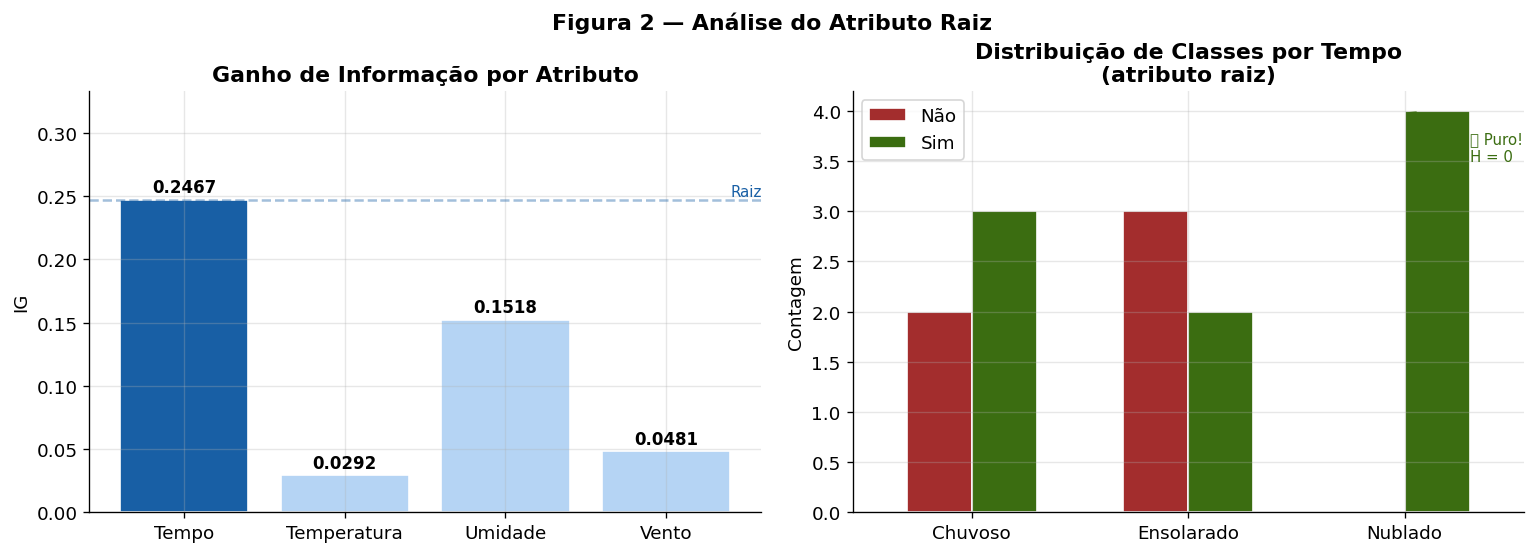

In [ ]:
# ============================================================
# GRÁFICO: Ganho de Informação por Atributo
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Barras de IG
cores = ['#185FA5' if a == vencedor else '#B5D4F4' for a in resultados.keys()]
bars = axes[0].bar(resultados.keys(), resultados.values(), color=cores, edgecolor='white')
axes[0].set_title('Ganho de Informação por Atributo', fontweight='bold')
axes[0].set_ylabel('IG')
axes[0].set_ylim(0, max(resultados.values()) * 1.35)
for bar, (attr, ig) in zip(bars, resultados.items()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{ig:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].axhline(resultados[vencedor], color='#185FA5', ls='--', alpha=0.4)
axes[0].text(3.4, resultados[vencedor]+0.003, 'Raiz', color='#185FA5', fontsize=9)

# Distribuição das classes por valor de Tempo
grupos = df.groupby(['Tempo', 'Jogar']).size().unstack(fill_value=0)
grupos.plot(kind='bar', ax=axes[1], color=['#A32D2D','#3B6D11'],
            edgecolor='white', width=0.6)
axes[1].set_title('Distribuição de Classes por Tempo\n(atributo raiz)', fontweight='bold')
axes[1].set_ylabel('Contagem')
axes[1].set_xlabel('')
axes[1].legend(['Não', 'Sim'])
axes[1].tick_params(axis='x', rotation=0)

# Anotação: Nublado é puro!
idx_nublado = list(grupos.index).index('Nublado')
axes[1].annotate('🎯 Puro!\nH = 0', xy=(idx_nublado, 4), xytext=(idx_nublado+0.3, 3.5),
                  fontsize=9, color='#3B6D11',
                  arrowprops=dict(arrowstyle='->', color='#3B6D11'))

plt.tight_layout()
plt.suptitle('Figura 2 — Análise do Atributo Raiz', y=1.02, fontweight='bold')
plt.savefig('fig2_ganho.png', bbox_inches='tight', dpi=130)
plt.show()

In [ ]:
# ============================================================
# DIAGRAMA: Árvore do Play Tennis (Mermaid)
# ============================================================
print("Árvore resultante do algoritmo ID3 — Play Tennis")
print("Profundidade = 2 | Folhas = 4 | Todas as folhas são puras!")

Árvore resultante do algoritmo ID3 — Play Tennis
Profundidade = 2 | Folhas = 4 | Todas as folhas são puras!


[![](https://mermaid.ink/img/pako:eNqdlM-K00Acx19lnL0opO1kMsk0QRfKtkphmy671cMaD9PMpC2mmTJNxNotLMjeBEE8eFA86iN49036AvoITpL-Zy82pyR8Pr_v7wuZzGEouYAeHCg2GYJeM0iAvi673d7DlwFcfrn98-sj6LU6F93HfXXafgaeAFTFhILl7Wdw2WhfB_DVo60EKpXTm1YylTFTjMsb4Jv5nL_fP_0AzzvtZqPZukfws35c0OcFvfx6B67anTyQ1EiRNMmUfHCPeTbM3shpnoNXOT_Bi5bf65ZsSftmwTbilOmIAlx--wD83--LUlbN2k5esb5UYxZr2jpYCNfw3mhc4E-lSoWmyeHsDb4LKxbmXe2D0Zs9SnqazmJRNo1Gceyd8L5gkTCmqZKvhXdiciJ43QhlLJV-Ehars11TNyk9gSK84yFcJyFdeygkzBF7Hj7OO1_n8TAKBd3u6TCLsM2exLYw3_OsIz37SG_dLxICC7zxeIgd7Kw9Gpnc3PfI_3jQgGOhv6ER14drns8JYDoUYxFAT99yEbEsTgMYJAuNsiyVV7MkhF6qMmFAJbPBEHoRi6f6KZtwlormiOlDOt68nbAEenP4FnoVWq0jhyKbupgiRJ26AWfQM12nqsubtk0xJRjZCwO-k1JPQFXXIS52qe3aCBMTuQYUfJRK1Sn_BsVPoYi4LoRyq4HK26w2FAkX6kxmSQo9bLmLf2nOVNk?type=png)](https://mermaid.live/edit#pako:eNqdlM-K00Acx19lnL0opO1kMsk0QRfKtkphmy671cMaD9PMpC2mmTJNxNotLMjeBEE8eFA86iN49036AvoITpL-Zy82pyR8Pr_v7wuZzGEouYAeHCg2GYJeM0iAvi673d7DlwFcfrn98-sj6LU6F93HfXXafgaeAFTFhILl7Wdw2WhfB_DVo60EKpXTm1YylTFTjMsb4Jv5nL_fP_0AzzvtZqPZukfws35c0OcFvfx6B67anTyQ1EiRNMmUfHCPeTbM3shpnoNXOT_Bi5bf65ZsSftmwTbilOmIAlx--wD83--LUlbN2k5esb5UYxZr2jpYCNfw3mhc4E-lSoWmyeHsDb4LKxbmXe2D0Zs9SnqazmJRNo1Gceyd8L5gkTCmqZKvhXdiciJ43QhlLJV-Ehars11TNyk9gSK84yFcJyFdeygkzBF7Hj7OO1_n8TAKBd3u6TCLsM2exLYw3_OsIz37SG_dLxICC7zxeIgd7Kw9Gpnc3PfI_3jQgGOhv6ER14drns8JYDoUYxFAT99yEbEsTgMYJAuNsiyVV7MkhF6qMmFAJbPBEHoRi6f6KZtwlormiOlDOt68nbAEenP4FnoVWq0jhyKbupgiRJ26AWfQM12nqsubtk0xJRjZCwO-k1JPQFXXIS52qe3aCBMTuQYUfJRK1Sn_BsVPoYi4LoRyq4HK26w2FAkX6kxmSQo9bLmLf2nOVNk)

Regras aprendidas pelo modelo:
|--- Tempo <= 1.50
|   |--- Umidade <= 0.50
|   |   |--- Tempo <= 0.50
|   |   |   |--- Vento <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Vento >  0.50
|   |   |   |   |--- class: 1
|   |   |--- Tempo >  0.50
|   |   |   |--- class: 0
|   |--- Umidade >  0.50
|   |   |--- Vento <= 0.50
|   |   |   |--- Temperatura <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Temperatura >  0.50
|   |   |   |   |--- class: 0
|   |   |--- Vento >  0.50
|   |   |   |--- class: 1
|--- Tempo >  1.50
|   |--- class: 1



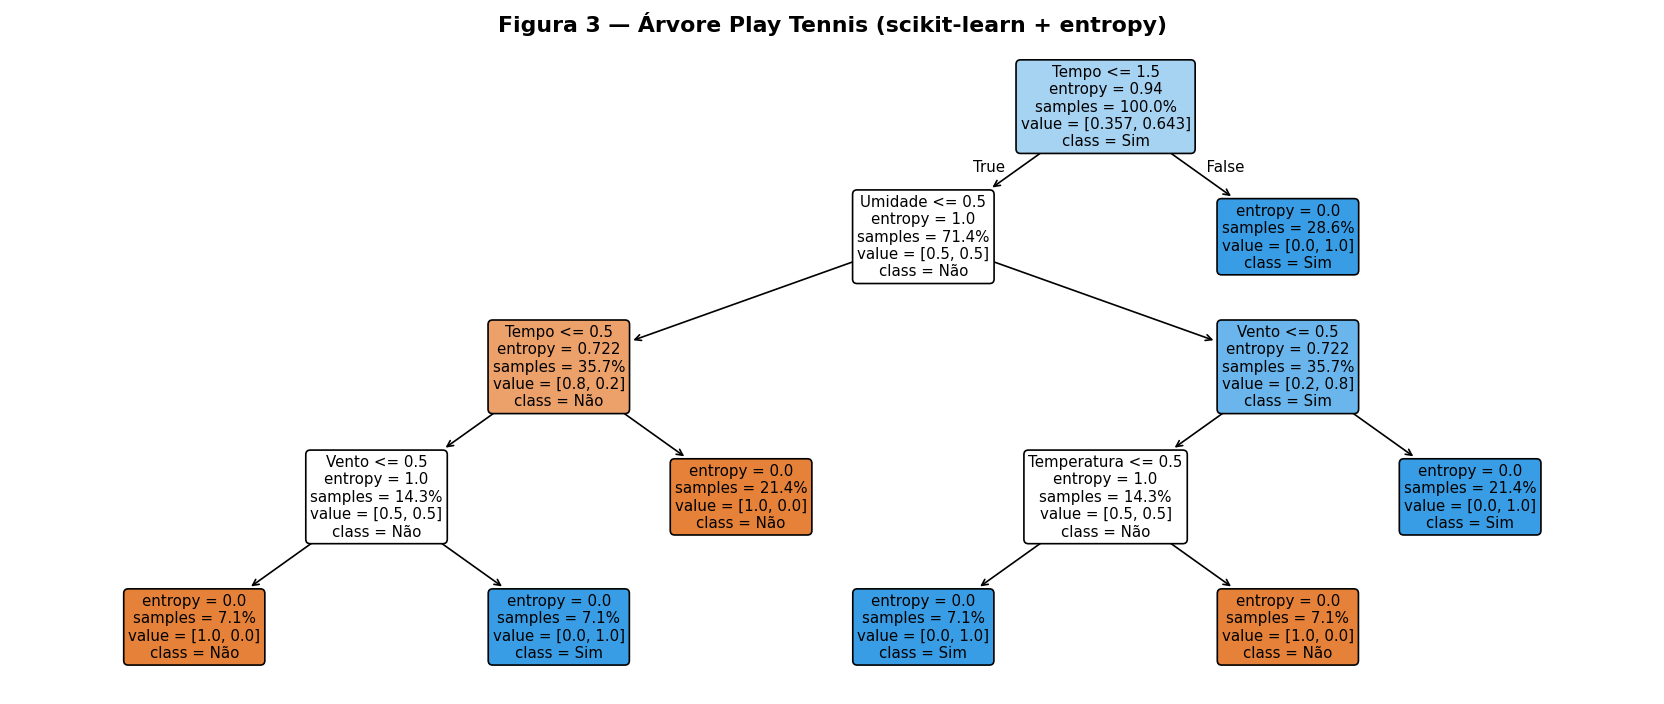


Acurácia no treino: 100.00%


In [ ]:
# ============================================================
# SCIKIT-LEARN: Play Tennis com codificação
# ============================================================
from sklearn.preprocessing import OrdinalEncoder

# Codificar atributos categóricos
X_raw = df[['Tempo', 'Temperatura', 'Umidade', 'Vento']]
y_raw = (df['Jogar'] == 'Sim').astype(int)

enc = OrdinalEncoder()
X_enc = enc.fit_transform(X_raw)

# Árvore sem restrições (vai aprender tudo)
clf_tennis = DecisionTreeClassifier(criterion='entropy', random_state=SEED)
clf_tennis.fit(X_enc, y_raw)

# Visualização textual
print('Regras aprendidas pelo modelo:')
print(export_text(clf_tennis, feature_names=['Tempo','Temperatura','Umidade','Vento']))

# Visualização gráfica
fig, ax = plt.subplots(figsize=(14, 6))
tree.plot_tree(
    clf_tennis,
    feature_names=['Tempo', 'Temperatura', 'Umidade', 'Vento'],
    class_names=['Não', 'Sim'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=True,
    proportion=True
)
ax.set_title('Figura 3 — Árvore Play Tennis (scikit-learn + entropy)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_arvore_tennis.png', bbox_inches='tight', dpi=130)
plt.show()
print(f'\nAcurácia no treino: {clf_tennis.score(X_enc, y_raw):.2%}')

---
## ⚖️ Overfitting, Underfitting e Poda


### O Dilema Viés × Variância

[![](https://mermaid.ink/img/pako:eNqFlE9u1DAUxq9iGbFiWpJ0kjSRQKraCo3UdlDpdAFB6E38MmOR2MGx0fQf4g50X6msWLCjJ5ibcAKOgJ1M25kK0axs6_uef--TX85oLhnSlE4U1FOyd5gJYr_GjLuD0cHO7uG7jP65urwhI8FQFVxrLibk99dLslVqIMd8_qPJ6PvO6b6Rbx0VzD4wrPWUVIZrSWr8ZFBIKyRray_JKLCag_l3SXKotVFAZENqYGp-gw-qBZ1hwxqOFHIhyRj4TJJn5Agbjd3uzoKCPehhsLO7tdf2cHVNXkthYebfNK_kyjUDB70tq7rEGWfAXN0SRI7A4BZ64KBfoUAFJT8FMsZqtUaHOlhChVLfk7rNf0CHx7dZ_yLDz_-KGhSfX4ucw8q1w9W8X5ADKfCWeeiY97GSyhErM__JVhsfdtDDJegvvuc9fSzf9mk463lGwVQoNCiSLwWY0fMu-07fLh_Tuwg6uVst1LVkVvqcKJyYElwf6kHtRp-UuCAqeFmmT9gYocBeo5X8iOkTn_WRbS6LO5yFOC9yjO_FEWz0YVncwnTaAjHA4E7L8iAKItqjFaoKOLOjdOacGdVTrGxPqV0yLMCUOqOZuLBSMFq-ORE5TbUy2KNKmsmUpgWUjd2ZmoHGHQ72UVR3pzUImp7RGU3X4vVNL4q9ME6C2PPiaLNHT2jqJ9F6uBH4YRgHcT_wwosePZXSVvDWk6ifBEkcJqEX9H0v6VFkdibVfjf77S-gveJta-ioJsp1syBEN_rb0ghN0yD0L_4CMaJX7A?type=png)](https://mermaid.live/edit#pako:eNqFlE9u1DAUxq9iGbFiWpJ0kjSRQKraCo3UdlDpdAFB6E38MmOR2MGx0fQf4g50X6msWLCjJ5ibcAKOgJ1M25kK0axs6_uef--TX85oLhnSlE4U1FOyd5gJYr_GjLuD0cHO7uG7jP65urwhI8FQFVxrLibk99dLslVqIMd8_qPJ6PvO6b6Rbx0VzD4wrPWUVIZrSWr8ZFBIKyRray_JKLCag_l3SXKotVFAZENqYGp-gw-qBZ1hwxqOFHIhyRj4TJJn5Agbjd3uzoKCPehhsLO7tdf2cHVNXkthYebfNK_kyjUDB70tq7rEGWfAXN0SRI7A4BZ64KBfoUAFJT8FMsZqtUaHOlhChVLfk7rNf0CHx7dZ_yLDz_-KGhSfX4ucw8q1w9W8X5ADKfCWeeiY97GSyhErM__JVhsfdtDDJegvvuc9fSzf9mk463lGwVQoNCiSLwWY0fMu-07fLh_Tuwg6uVst1LVkVvqcKJyYElwf6kHtRp-UuCAqeFmmT9gYocBeo5X8iOkTn_WRbS6LO5yFOC9yjO_FEWz0YVncwnTaAjHA4E7L8iAKItqjFaoKOLOjdOacGdVTrGxPqV0yLMCUOqOZuLBSMFq-ORE5TbUy2KNKmsmUpgWUjd2ZmoHGHQ72UVR3pzUImp7RGU3X4vVNL4q9ME6C2PPiaLNHT2jqJ9F6uBH4YRgHcT_wwosePZXSVvDWk6ifBEkcJqEX9H0v6VFkdibVfjf77S-gveJta-ioJsp1syBEN_rb0ghN0yD0L_4CMaJX7A)


### Hiperparâmetros do CART (scikit-learn)

| Parâmetro | Padrão | Efeito | Para corrigir overfitting |
|---|---|---|---|
| `max_depth` | `None` | Profundidade máxima | Diminuir |
| `min_samples_split` | `2` | Mín. amostras para dividir | Aumentar |
| `min_samples_leaf` | `1` | Mín. amostras em folha | Aumentar |
| `max_features` | `None` | Atributos por divisão | Diminuir |
| `max_leaf_nodes` | `None` | Máximo de folhas | Limitar |
| `ccp_alpha` | `0.0` | Pós-poda custo-complexidade | Aumentar |



### Estratégias Anti-Overfitting

[![](https://mermaid.ink/img/pako:eNqNlMtu1DAUhl_FcjeAZqrEuTURdEEvu6qjAXUBg0an8clMqGNHtjOiUxWJp2DFAlgg1uzY5k14EpyknbaoQpNNbt93fH7byRXNFUea0YWGekleH84kccdkevryydsZ_fPlMzldoS5Ka0u5IBwt5ha4mtF3T-9QMh7vk4nvhIluf44nisPzc71fwYc5x9ouR6Qq5dxAVQs082dO_tdlndv-Mhs3z-s5iHoJj8CBg89AlBzaH-13RQ50s4ZBuxgfK8HJwdkjWui0I2mwOhfYsVOQXFXkWGk0tudvDL_np12e9pNeufckd0zuTkparcTNYH22F8HHhDSmAXE3JBsKdKGmWKkVEtOcj9uvfS3Tqa4LsgC5VETjfTMYzC7hkbFlBWSBErULux7C3sqNAd21876RVrl1IdaFwLtC4VCoy3zS_ha2rAUYctsC0WCgb0Qjb9ZkBbpsv8m8hHvzYOylwGH-ilKIbKdAZMhGxk3BBWY7PGcxix-w_oYs0jzYkDnsgRc-INnWZLA1GW5LTm_75HmRY7Ih_RiCEB6QbGsy2JoM_0fSEa1QV1By91Vedd6M2iVWbm0zd8mxgEa47TqT1w6FxqpXlzKnmdUNjqhWzWJJswKEcXdNzcHiYQnu6642T2uQNLuiH2g2Tnb3vDjxoiRliecl8d6IXtLMT-PdKGB-FCUsCZkXXY_oWilXwdtN4zBlaRKlkcdC33MC8tIqfTL8Rvq_ST_Em14YulroLs1Nhyg56gPl9i3NWJRe_wXpWnTp?type=png)](https://mermaid.live/edit#pako:eNqNlMtu1DAUhl_FcjeAZqrEuTURdEEvu6qjAXUBg0an8clMqGNHtjOiUxWJp2DFAlgg1uzY5k14EpyknbaoQpNNbt93fH7byRXNFUea0YWGekleH84kccdkevryydsZ_fPlMzldoS5Ka0u5IBwt5ha4mtF3T-9QMh7vk4nvhIluf44nisPzc71fwYc5x9ouR6Qq5dxAVQs082dO_tdlndv-Mhs3z-s5iHoJj8CBg89AlBzaH-13RQ50s4ZBuxgfK8HJwdkjWui0I2mwOhfYsVOQXFXkWGk0tudvDL_np12e9pNeufckd0zuTkparcTNYH22F8HHhDSmAXE3JBsKdKGmWKkVEtOcj9uvfS3Tqa4LsgC5VETjfTMYzC7hkbFlBWSBErULux7C3sqNAd21876RVrl1IdaFwLtC4VCoy3zS_ha2rAUYctsC0WCgb0Qjb9ZkBbpsv8m8hHvzYOylwGH-ilKIbKdAZMhGxk3BBWY7PGcxix-w_oYs0jzYkDnsgRc-INnWZLA1GW5LTm_75HmRY7Ih_RiCEB6QbGsy2JoM_0fSEa1QV1By91Vedd6M2iVWbm0zd8mxgEa47TqT1w6FxqpXlzKnmdUNjqhWzWJJswKEcXdNzcHiYQnu6642T2uQNLuiH2g2Tnb3vDjxoiRliecl8d6IXtLMT-PdKGB-FCUsCZkXXY_oWilXwdtN4zBlaRKlkcdC33MC8tIqfTL8Rvq_ST_Em14YulroLs1Nhyg56gPl9i3NWJRe_wXpWnTp)

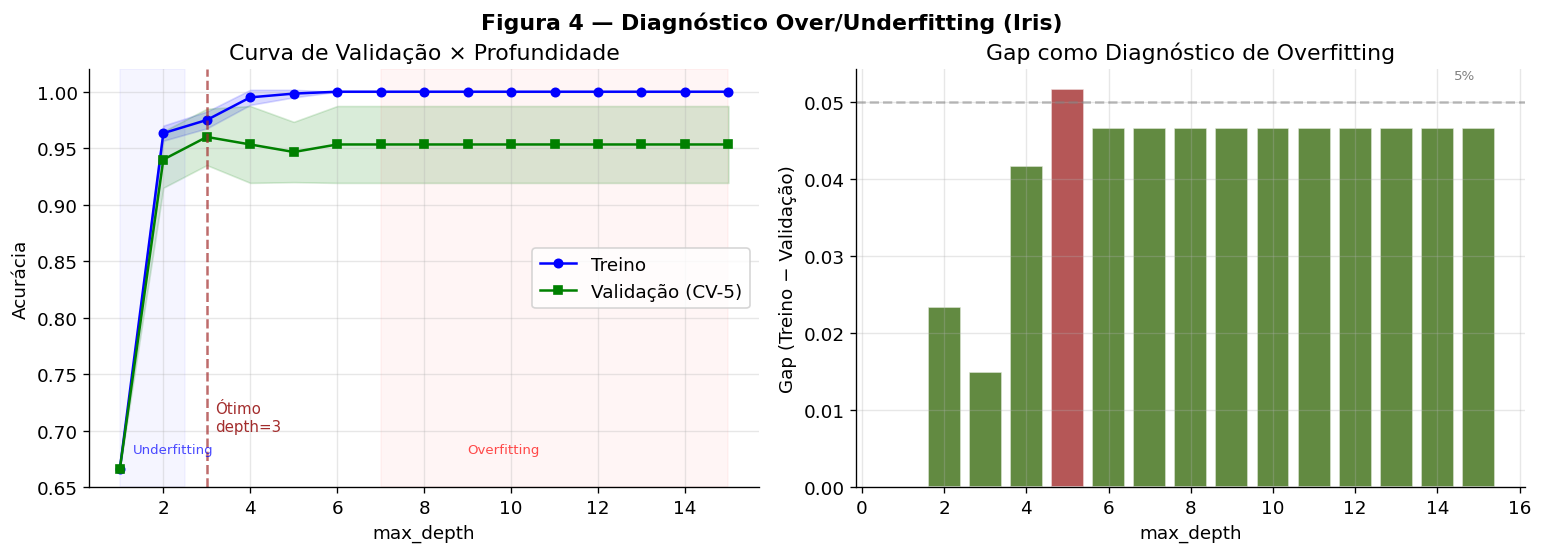

Melhor profundidade (CV-5): 3
Acurácia validação:         0.960 ± 0.025


In [ ]:
# ============================================================
# DEMONSTRAÇÃO: Curva de Validação × max_depth — Iris
# ============================================================
iris = datasets.load_iris()
X_iris, y_iris = iris.data, iris.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=SEED, stratify=y_iris
)

# Curva de validação
depths = np.arange(1, 16)
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=SEED),
    X_iris, y_iris,
    param_name='max_depth',
    param_range=depths,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='accuracy'
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

# ─── GRÁFICO ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(depths, train_mean, 'b-o', ms=5, label='Treino')
ax.fill_between(depths, train_mean-train_std, train_mean+train_std, alpha=0.15, color='blue')
ax.plot(depths, val_mean, 'g-s', ms=5, label='Validação (CV-5)')
ax.fill_between(depths, val_mean-val_std, val_mean+val_std, alpha=0.15, color='green')
best_depth = depths[np.argmax(val_mean)]
ax.axvline(best_depth, color='#A32D2D', ls='--', lw=1.5, alpha=0.7)
ax.text(best_depth+0.2, 0.7, f'Ótimo\ndepth={best_depth}', color='#A32D2D', fontsize=9)
ax.set_xlabel('max_depth')
ax.set_ylabel('Acurácia')
ax.set_title('Curva de Validação × Profundidade')
ax.legend()
ax.set_ylim(0.65, 1.02)

# Anotações de região
ax.axvspan(1, 2.5, alpha=0.04, color='blue')
ax.text(1.3, 0.68, 'Underfitting', color='blue', fontsize=8, alpha=0.7)
ax.axvspan(7, 15, alpha=0.04, color='red')
ax.text(9, 0.68, 'Overfitting', color='red', fontsize=8, alpha=0.7)

# Gap treino-validação
ax2 = axes[1]
gap = train_mean - val_mean
ax2.bar(depths, gap, color=['#3B6D11' if g < 0.05 else '#A32D2D' for g in gap],
        alpha=0.8, edgecolor='white')
ax2.axhline(0.05, color='gray', ls='--', alpha=0.5)
ax2.text(14.4, 0.053, '5%', fontsize=8, color='gray')
ax2.set_xlabel('max_depth')
ax2.set_ylabel('Gap (Treino − Validação)')
ax2.set_title('Gap como Diagnóstico de Overfitting')

plt.tight_layout()
plt.suptitle('Figura 4 — Diagnóstico Over/Underfitting (Iris)', y=1.02, fontweight='bold')
plt.savefig('fig4_validacao.png', bbox_inches='tight', dpi=130)
plt.show()

print(f'Melhor profundidade (CV-5): {best_depth}')
print(f'Acurácia validação:         {val_mean[best_depth-1]:.3f} ± {val_std[best_depth-1]:.3f}')

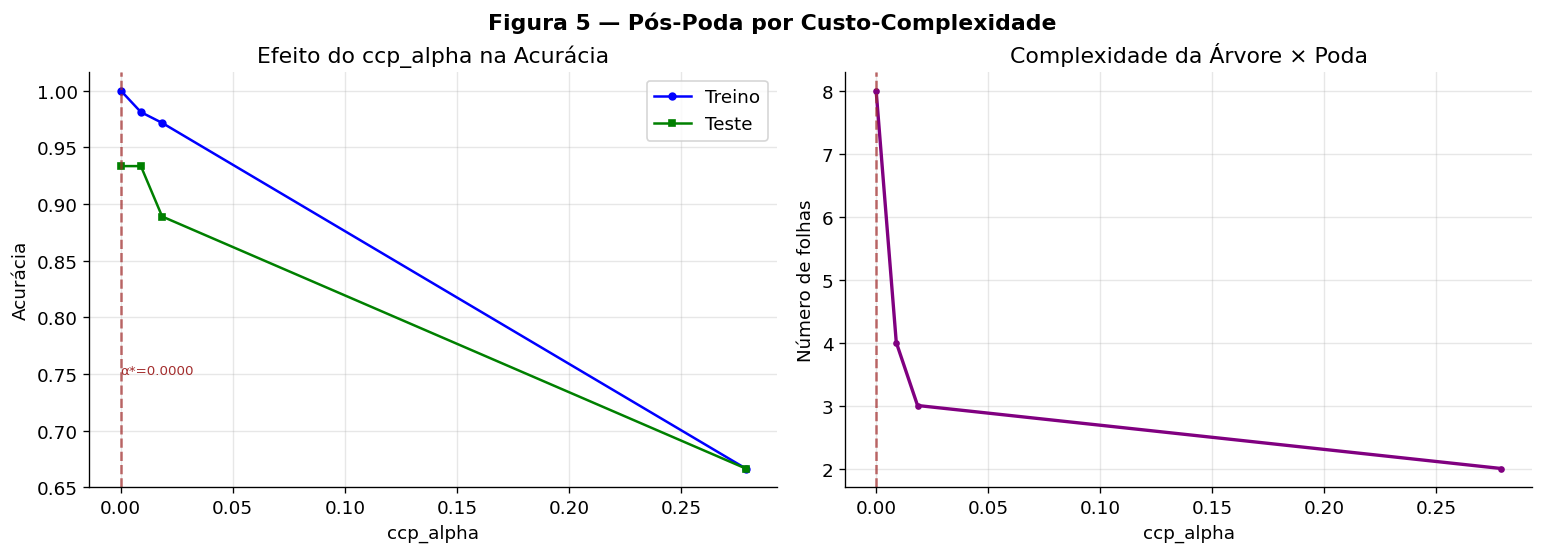

Alpha ótimo:    0.0000
Acurácia teste: 0.933
Número de folhas após poda: 8


In [ ]:
# ============================================================
# PÓS-PODA: Cost-Complexity Pruning (ccp_alpha)
# ============================================================
clf_full = DecisionTreeClassifier(random_state=SEED)
path = clf_full.cost_complexity_pruning_path(X_tr, y_tr)
ccp_alphas = path.ccp_alphas[:-1]  # remove alfa final (nó raiz apenas)
impurities = path.impurities[:-1]

# Treinar um modelo por alpha
clfs_pruned = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(ccp_alpha=alpha, random_state=SEED)
    clf.fit(X_tr, y_tr)
    clfs_pruned.append(clf)

train_accs = [c.score(X_tr, y_tr) for c in clfs_pruned]
test_accs  = [c.score(X_te, y_te) for c in clfs_pruned]
n_leaves   = [c.get_n_leaves() for c in clfs_pruned]

best_idx = np.argmax(test_accs)
best_alpha = ccp_alphas[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(ccp_alphas, train_accs, 'b-o', ms=4, label='Treino')
axes[0].plot(ccp_alphas, test_accs,  'g-s', ms=4, label='Teste')
axes[0].axvline(best_alpha, color='#A32D2D', ls='--', lw=1.5, alpha=0.7)
axes[0].text(best_alpha*1.05, 0.75, f'α*={best_alpha:.4f}', color='#A32D2D', fontsize=8)
axes[0].set_xlabel('ccp_alpha')
axes[0].set_ylabel('Acurácia')
axes[0].set_title('Efeito do ccp_alpha na Acurácia')
axes[0].legend()

axes[1].plot(ccp_alphas, n_leaves, 'purple', lw=2, marker='o', ms=3)
axes[1].axvline(best_alpha, color='#A32D2D', ls='--', lw=1.5, alpha=0.7)
axes[1].set_xlabel('ccp_alpha')
axes[1].set_ylabel('Número de folhas')
axes[1].set_title('Complexidade da Árvore × Poda')

plt.tight_layout()
plt.suptitle('Figura 5 — Pós-Poda por Custo-Complexidade', y=1.02, fontweight='bold')
plt.savefig('fig5_poda.png', bbox_inches='tight', dpi=130)
plt.show()

print(f'Alpha ótimo:    {best_alpha:.4f}')
print(f'Acurácia teste: {test_accs[best_idx]:.3f}')
print(f'Número de folhas após poda: {n_leaves[best_idx]}')

---
## 💻 Pipeline Completo: Iris


### Fluxo de Trabalho

[![](https://mermaid.ink/img/pako:eNpdk9Fq2zAUhl9FqBQ2SFrHiePYbIU2KSHQjJB0vtgywol0XIvKlpHkrmnoC-x2F7scbBd7gD1CXmiPMNkpaamvLOv7_nOOkLeUKY40pqlUX1kG2pKr-bIg7hm9-byk_35-_0ZGYMGgXdIvb0m7fUYWbuNagyhOr9FYsiilsO_W-iz0jskp6XrHjtxnLBp-mDhhqJUx7QSk4GCFKmrh9n1AFla7dSqQH6xh0mjjus5YC75A0CwbJrWSw_2KY2kzsvtBclGsDOSlRFMvmRYWtcs-JI33DVxMXdIUZaY0mbp5pToQF9OGSCZ1sUSYyjX4ALs_u9-qLldKZVdWI74WZvOPHy6dMtv9Ne2Z4lDTjJUrkGUGr-nL5PzKwed3Lv05fCjBGDc6aw6EzLFU2h7U2mnkyXTm3Ele7-5-FUw0tbgy5Nxqsa6sMo2014zdSCQjkgop4yO-RkixZaxWtxgfdXgP-eAl6Bp8IlnKMHwm-9DtwUuy6WfPpphGrHtgGQzA69EWzVHnILi7TtvaXFKbYe6OLnavHFOopBtvWTw6FFzbi03BaGx1hS2qVXWT0TgFadyqKt0lwZGAGw354WsJBY239J7G7fBk4PVDLwgjP_S8sD9o0Q2NO1H_JOj6nSAI_bDne8Fjiz4o5RK8k6jfi_woDKLA83sdL2pR5MIqPd3f_-Y3aEp8aoR9Vze6nuapQyw46qGqCktjvx8-_gdmzwou?type=png)](https://mermaid.live/edit#pako:eNpdk9Fq2zAUhl9FqBQ2SFrHiePYbIU2KSHQjJB0vtgywol0XIvKlpHkrmnoC-x2F7scbBd7gD1CXmiPMNkpaamvLOv7_nOOkLeUKY40pqlUX1kG2pKr-bIg7hm9-byk_35-_0ZGYMGgXdIvb0m7fUYWbuNagyhOr9FYsiilsO_W-iz0jskp6XrHjtxnLBp-mDhhqJUx7QSk4GCFKmrh9n1AFla7dSqQH6xh0mjjus5YC75A0CwbJrWSw_2KY2kzsvtBclGsDOSlRFMvmRYWtcs-JI33DVxMXdIUZaY0mbp5pToQF9OGSCZ1sUSYyjX4ALs_u9-qLldKZVdWI74WZvOPHy6dMtv9Ne2Z4lDTjJUrkGUGr-nL5PzKwed3Lv05fCjBGDc6aw6EzLFU2h7U2mnkyXTm3Ele7-5-FUw0tbgy5Nxqsa6sMo2014zdSCQjkgop4yO-RkixZaxWtxgfdXgP-eAl6Bp8IlnKMHwm-9DtwUuy6WfPpphGrHtgGQzA69EWzVHnILi7TtvaXFKbYe6OLnavHFOopBtvWTw6FFzbi03BaGx1hS2qVXWT0TgFadyqKt0lwZGAGw354WsJBY239J7G7fBk4PVDLwgjP_S8sD9o0Q2NO1H_JOj6nSAI_bDne8Fjiz4o5RK8k6jfi_woDKLA83sdL2pR5MIqPd3f_-Y3aEp8aoR9Vze6nuapQyw46qGqCktjvx8-_gdmzwou)

In [ ]:
# ============================================================
# PIPELINE COMPLETO — Iris
# ============================================================

# --- GridSearchCV ---
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, None],
    'min_samples_leaf': [1, 3, 5],
    'min_samples_split': [2, 5, 10],
}

gs = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED),
    param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
gs.fit(X_tr, y_tr)

print('=== GridSearchCV — Melhores Hiperparâmetros ===')
for k, v in gs.best_params_.items():
    print(f'  {k:25s}: {v}')
print(f'  Acurácia CV (treino):    {gs.best_score_:.4f}')

clf_best = gs.best_estimator_
y_pred = clf_best.predict(X_te)

print(f'\n  Acurácia (teste holdout): {accuracy_score(y_te, y_pred):.4f}')
print(f'  Profundidade:             {clf_best.get_depth()}')
print(f'  Número de folhas:         {clf_best.get_n_leaves()}')

print('\n=== Relatório de Classificação ===')
print(classification_report(y_te, y_pred, target_names=iris.target_names))

=== GridSearchCV — Melhores Hiperparâmetros ===
  criterion                : gini
  max_depth                : 3
  min_samples_leaf         : 1
  min_samples_split        : 2
  Acurácia CV (treino):    0.9524

  Acurácia (teste holdout): 0.9778
  Profundidade:             3
  Número de folhas:         5

=== Relatório de Classificação ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.93      0.97        15
   virginica       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



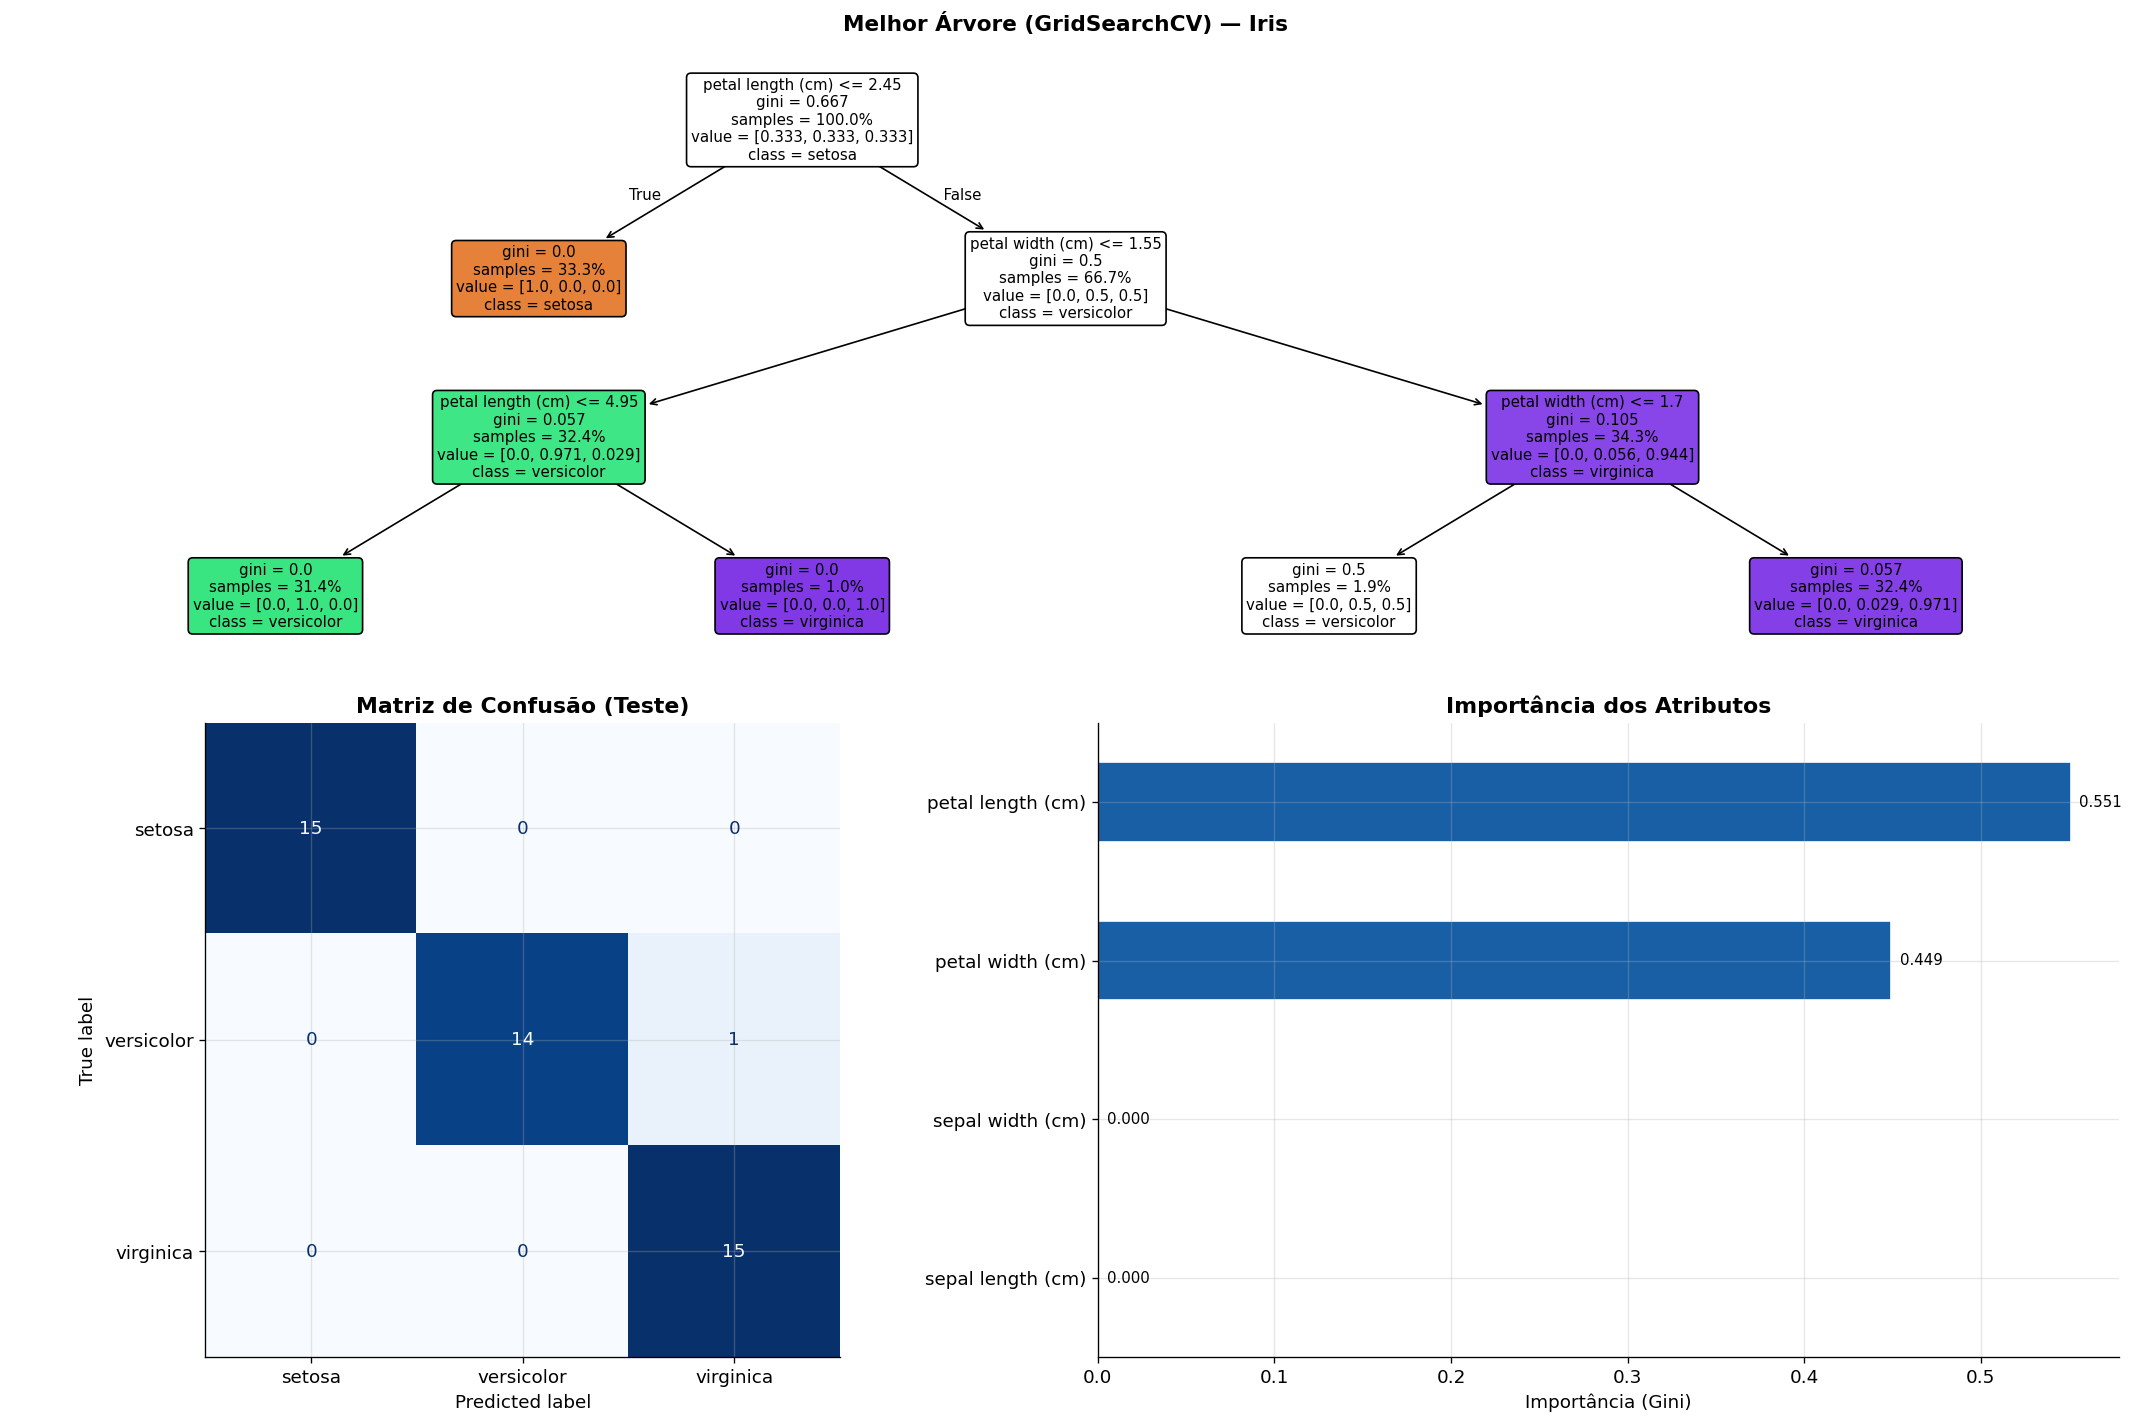

In [ ]:
# ============================================================
# VISUALIZAÇÃO: Árvore + Matriz de Confusão + Importância
# ============================================================
fig = plt.figure(figsize=(18, 12))

# Árvore
ax_tree = fig.add_subplot(2, 2, (1, 2))
tree.plot_tree(
    clf_best,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax_tree,
    proportion=True,
    impurity=True
)
ax_tree.set_title('Melhor Árvore (GridSearchCV) — Iris', fontweight='bold', fontsize=13)

# Matriz de confusão
ax_cm = fig.add_subplot(2, 2, 3)
ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred,
    display_labels=iris.target_names,
    ax=ax_cm,
    colorbar=False,
    cmap='Blues'
)
ax_cm.set_title('Matriz de Confusão (Teste)', fontweight='bold')

# Importância dos atributos
ax_fi = fig.add_subplot(2, 2, 4)
fi = pd.Series(clf_best.feature_importances_, index=iris.feature_names).sort_values()
colors = ['#185FA5' if v > 0.3 else '#B5D4F4' for v in fi]
fi.plot(kind='barh', ax=ax_fi, color=colors, edgecolor='white')
ax_fi.set_title('Importância dos Atributos', fontweight='bold')
ax_fi.set_xlabel('Importância (Gini)')
for i, v in enumerate(fi):
    ax_fi.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig6_pipeline_iris.png', bbox_inches='tight', dpi=130)
plt.show()

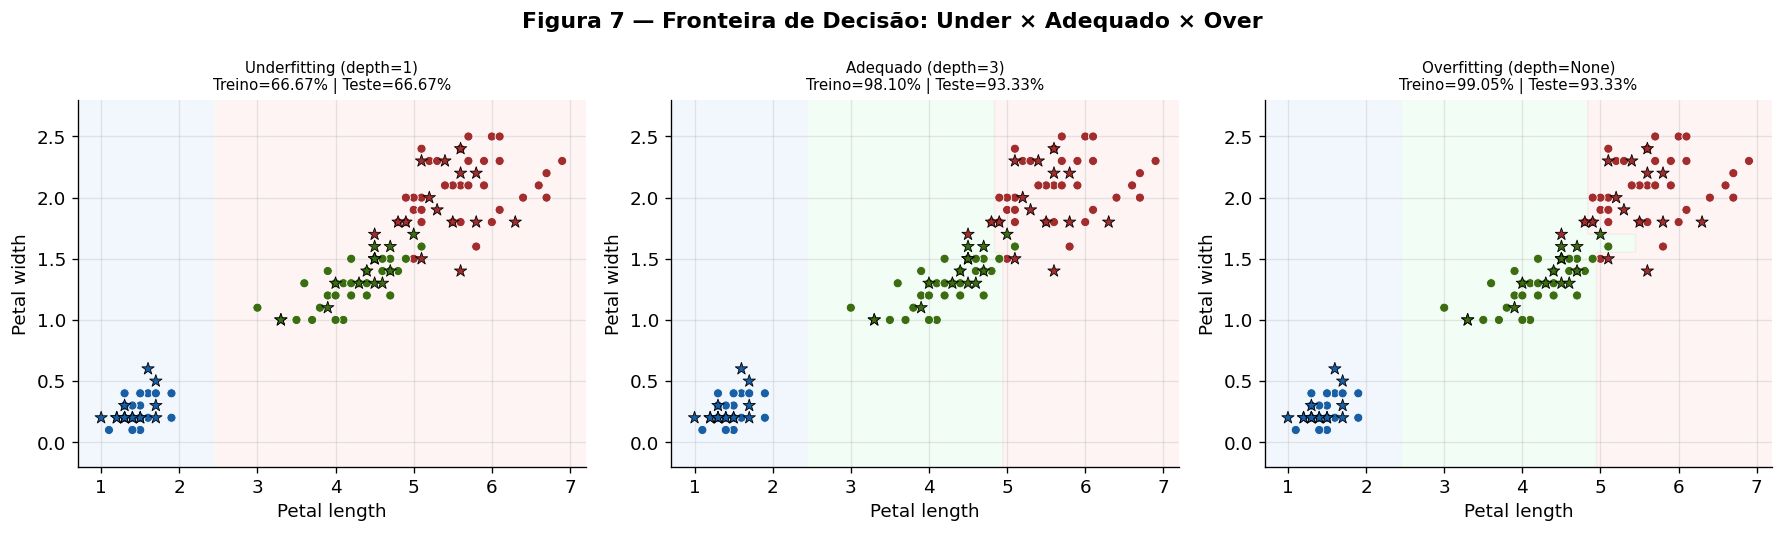

In [ ]:
# ============================================================
# FRONTEIRA DE DECISÃO — 2D (petal length × petal width)
# ============================================================
X_2d = X_iris[:, 2:4]  # petal length, petal width
X_2d_tr, X_2d_te, y_2d_tr, y_2d_te = train_test_split(
    X_2d, y_iris, test_size=0.3, random_state=SEED, stratify=y_iris
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
depths = [1, 3, None]
titles = ['Underfitting (depth=1)', 'Adequado (depth=3)', 'Overfitting (depth=None)']
cores_mapa = ['#dbeafe', '#dcfce7', '#fee2e2']

for ax, d, tit in zip(axes, depths, titles):
    clf2d = DecisionTreeClassifier(max_depth=d, random_state=SEED)
    clf2d.fit(X_2d_tr, y_2d_tr)

    x_min, x_max = X_2d[:,0].min()-0.3, X_2d[:,0].max()+0.3
    y_min, y_max = X_2d[:,1].min()-0.3, X_2d[:,1].max()+0.3
    xx, yy = np.meshgrid(np.linspace(x_min,x_max,300), np.linspace(y_min,y_max,300))
    Z = clf2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    from matplotlib.colors import ListedColormap
    cmap_bg = ListedColormap(['#dbeafe','#dcfce7','#fee2e2'])
    cmap_pt = ListedColormap(['#185FA5','#3B6D11','#A32D2D'])
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg)
    ax.scatter(X_2d_tr[:,0], X_2d_tr[:,1], c=y_2d_tr, cmap=cmap_pt,
               s=30, edgecolors='white', lw=0.5, zorder=3, label='Treino')
    ax.scatter(X_2d_te[:,0], X_2d_te[:,1], c=y_2d_te, cmap=cmap_pt,
               s=60, marker='*', edgecolors='black', lw=0.5, zorder=4, label='Teste')

    tr_acc = clf2d.score(X_2d_tr, y_2d_tr)
    te_acc = clf2d.score(X_2d_te, y_2d_te)
    ax.set_title(f'{tit}\nTreino={tr_acc:.2%} | Teste={te_acc:.2%}', fontsize=9)
    ax.set_xlabel('Petal length')
    ax.set_ylabel('Petal width')

plt.suptitle('Figura 7 — Fronteira de Decisão: Under × Adequado × Over', fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_fronteira.png', bbox_inches='tight', dpi=130)
plt.show()

---
## 🔬 Comparação Gini × Entropia × Log-loss

### Quando cada critério é preferível?

[![](https://mermaid.ink/img/pako:eNpdk99umzAUh1_F8m5aKY2AhBDQ1KlaoqhS0z9Jrjam6QCHxKrBmQ3d0jTSbne_F5imaerFLvcEvEmfZDZkDRtXYP2-c75jmy2NRYI0oCkXH-MVyIIsRmFO9DNfnM0WR29DOlax4CuUJJasqB4lEyRBwrJ1KfEeQvruuAWQk5NTcmNvQ3otRcQxA1I9vozkqUYkLiUqVX0Xr0K6a6Ab2xAPc5Y9kNl4ottN52MiSjI9GxtshDFTTOQLiThreCF1z3_oS13ygdw4dVcDgDY09Fo7QMQ4SyBBRSLMzGoMnEUSElAtD-fgcXE1ubiaz7ULF8v3XChlqCN1yxFkTp6-_CB21z4-WDhti562GEEBCgsSi6YhB6V0_6xkhWg2Q0XAIY_xP4vewWJ8uZiZ3c8LKdYbQ02BKaIwV9WvO-QE6gnxQ4k5KHIHkkH1s_qN6iDWa4lNzi_Pdb0Jy5kBryGRep08ff5KZPVtzZLaTJ-SiEpViLpIU0YVG47mdEjKOA9epJj6ca-jtNgtBi9iGILVb0f3G_g3HqOXHuIR2kM3acfNpPssWqmT4nPWcob92GtnzRT7bBKbys9ZewC9PtAOzVBmwBJ9qbeGDGmxwgxDGujXBFMoeRHSMN_pKJSFmG_ymAaFLLFDpSiXKxqkwJX-KtcJFDhisJSQPa-uIafBln6iwYnXHVoDz3I93_EsyxsMO3RDA9sfdN2eY7uu53h9x3J3HXovhK5gdf1B33d8z_Vdy-nblgYw0XdCTpu_sP4Z6xZvaqCxWkozzd4Q8wTla1HmBQ0cz939Ad1UPaY?type=png)](https://mermaid.live/edit#pako:eNpdk99umzAUh1_F8m5aKY2AhBDQ1KlaoqhS0z9Jrjam6QCHxKrBmQ3d0jTSbne_F5imaerFLvcEvEmfZDZkDRtXYP2-c75jmy2NRYI0oCkXH-MVyIIsRmFO9DNfnM0WR29DOlax4CuUJJasqB4lEyRBwrJ1KfEeQvruuAWQk5NTcmNvQ3otRcQxA1I9vozkqUYkLiUqVX0Xr0K6a6Ab2xAPc5Y9kNl4ottN52MiSjI9GxtshDFTTOQLiThreCF1z3_oS13ygdw4dVcDgDY09Fo7QMQ4SyBBRSLMzGoMnEUSElAtD-fgcXE1ubiaz7ULF8v3XChlqCN1yxFkTp6-_CB21z4-WDhti562GEEBCgsSi6YhB6V0_6xkhWg2Q0XAIY_xP4vewWJ8uZiZ3c8LKdYbQ02BKaIwV9WvO-QE6gnxQ4k5KHIHkkH1s_qN6iDWa4lNzi_Pdb0Jy5kBryGRep08ff5KZPVtzZLaTJ-SiEpViLpIU0YVG47mdEjKOA9epJj6ca-jtNgtBi9iGILVb0f3G_g3HqOXHuIR2kM3acfNpPssWqmT4nPWcob92GtnzRT7bBKbys9ZewC9PtAOzVBmwBJ9qbeGDGmxwgxDGujXBFMoeRHSMN_pKJSFmG_ymAaFLLFDpSiXKxqkwJX-KtcJFDhisJSQPa-uIafBln6iwYnXHVoDz3I93_EsyxsMO3RDA9sfdN2eY7uu53h9x3J3HXovhK5gdf1B33d8z_Vdy-nblgYw0XdCTpu_sP4Z6xZvaqCxWkozzd4Q8wTla1HmBQ0cz939Ad1UPaY)

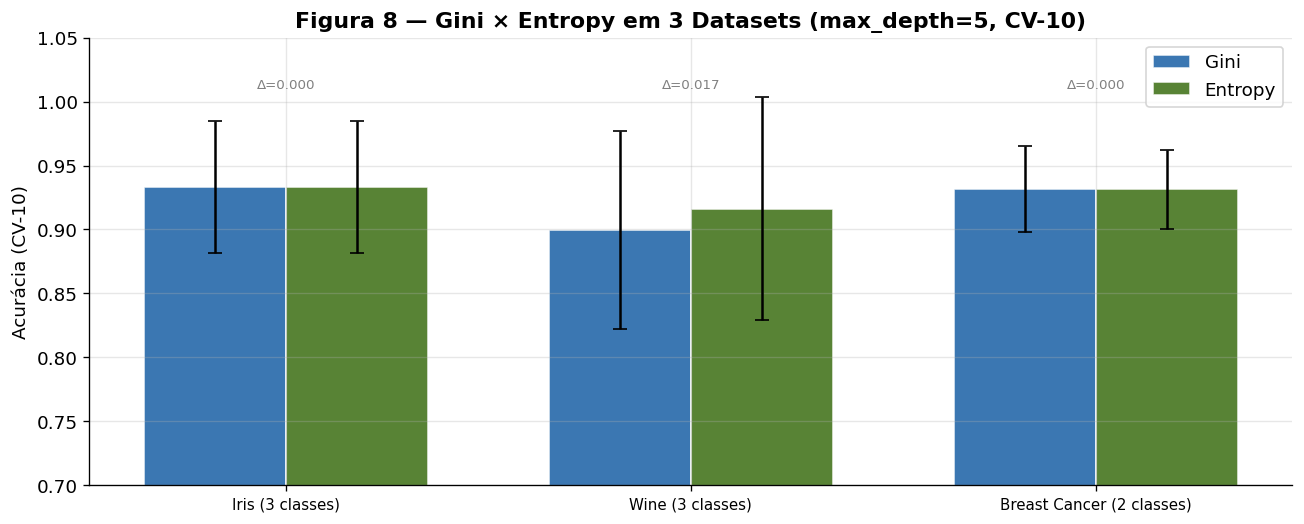

Critério                    entropy      gini
Dataset                                      
Breast Cancer (2 classes)  0.931516  0.931516
Iris (3 classes)           0.933333  0.933333
Wine (3 classes)           0.916340  0.899673

→ Diferenças geralmente < 1%. Escolha Gini por padrão.


In [ ]:
# ============================================================
# COMPARAÇÃO: Gini × Entropia em múltiplos datasets
# ============================================================
from sklearn.datasets import load_wine, load_breast_cancer

datasets_list = {
    'Iris (3 classes)': datasets.load_iris(),
    'Wine (3 classes)': load_wine(),
    'Breast Cancer (2 classes)': load_breast_cancer(),
}

resultados_comp = []
for nome, ds in datasets_list.items():
    Xd, yd = ds.data, ds.target
    for criterio in ['gini', 'entropy']:
        accs = cross_val_score(
            DecisionTreeClassifier(criterion=criterio, max_depth=5, random_state=SEED),
            Xd, yd,
            cv=StratifiedKFold(10, shuffle=True, random_state=SEED),
            scoring='accuracy'
        )
        resultados_comp.append({
            'Dataset': nome, 'Critério': criterio,
            'Média': accs.mean(), 'Std': accs.std()
        })

df_comp = pd.DataFrame(resultados_comp)

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(datasets_list))
w = 0.35
gini_rows  = df_comp[df_comp['Critério']=='gini'].reset_index(drop=True)
entr_rows  = df_comp[df_comp['Critério']=='entropy'].reset_index(drop=True)

b1 = ax.bar(x - w/2, gini_rows['Média'], w, yerr=gini_rows['Std'],
             color='#185FA5', alpha=0.85, label='Gini', capsize=4, edgecolor='white')
b2 = ax.bar(x + w/2, entr_rows['Média'], w, yerr=entr_rows['Std'],
             color='#3B6D11', alpha=0.85, label='Entropy', capsize=4, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(list(datasets_list.keys()), fontsize=9)
ax.set_ylabel('Acurácia (CV-10)')
ax.set_title('Figura 8 — Gini × Entropy em 3 Datasets (max_depth=5, CV-10)', fontweight='bold')
ax.legend()
ax.set_ylim(0.7, 1.05)

# Anotar diferença
for i in range(len(x)):
    diff = abs(gini_rows['Média'][i] - entr_rows['Média'][i])
    ax.text(x[i], 1.01, f'Δ={diff:.3f}', ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('fig8_gini_entropy.png', bbox_inches='tight', dpi=130)
plt.show()
print(df_comp.pivot(index='Dataset', columns='Critério', values='Média').to_string())
print('\n→ Diferenças geralmente < 1%. Escolha Gini por padrão.')

---
## 🏆 Pipeline Avançado: Breast Cancer

Aplicação completa com GridSearchCV, poda, avaliação e interpretabilidade.

In [ ]:
# ============================================================
# PIPELINE AVANÇADO: Breast Cancer
# ============================================================
bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target

X_bc_tr, X_bc_te, y_bc_tr, y_bc_te = train_test_split(
    X_bc, y_bc, test_size=0.3, random_state=SEED, stratify=y_bc
)

# GridSearchCV com F1 (classe maligna = 0)
param_grid_bc = {
    'criterion':          ['gini', 'entropy'],
    'max_depth':          [3, 5, 7, None],
    'min_samples_leaf':   [1, 5, 10],
    'min_samples_split':  [2, 10, 20],
}

gs_bc = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED),
    param_grid_bc,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='f1',
    n_jobs=-1
)
gs_bc.fit(X_bc_tr, y_bc_tr)

clf_bc = gs_bc.best_estimator_
y_bc_pred = clf_bc.predict(X_bc_te)

print('=== Breast Cancer — Melhores Hiperparâmetros ===')
print(gs_bc.best_params_)
print(f'\nF1 (CV):   {gs_bc.best_score_:.4f}')
print(f'Profundidade: {clf_bc.get_depth()} | Folhas: {clf_bc.get_n_leaves()}')

print('\n=== Relatório de Classificação ===')
print(classification_report(y_bc_te, y_bc_pred, target_names=bc.target_names))

=== Breast Cancer — Melhores Hiperparâmetros ===
{'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 10, 'min_samples_split': 2}

F1 (CV):   0.9536
Profundidade: 3 | Folhas: 6

=== Relatório de Classificação ===
              precision    recall  f1-score   support

   malignant       0.89      0.92      0.91        64
      benign       0.95      0.93      0.94       107

    accuracy                           0.93       171
   macro avg       0.92      0.93      0.93       171
weighted avg       0.93      0.93      0.93       171



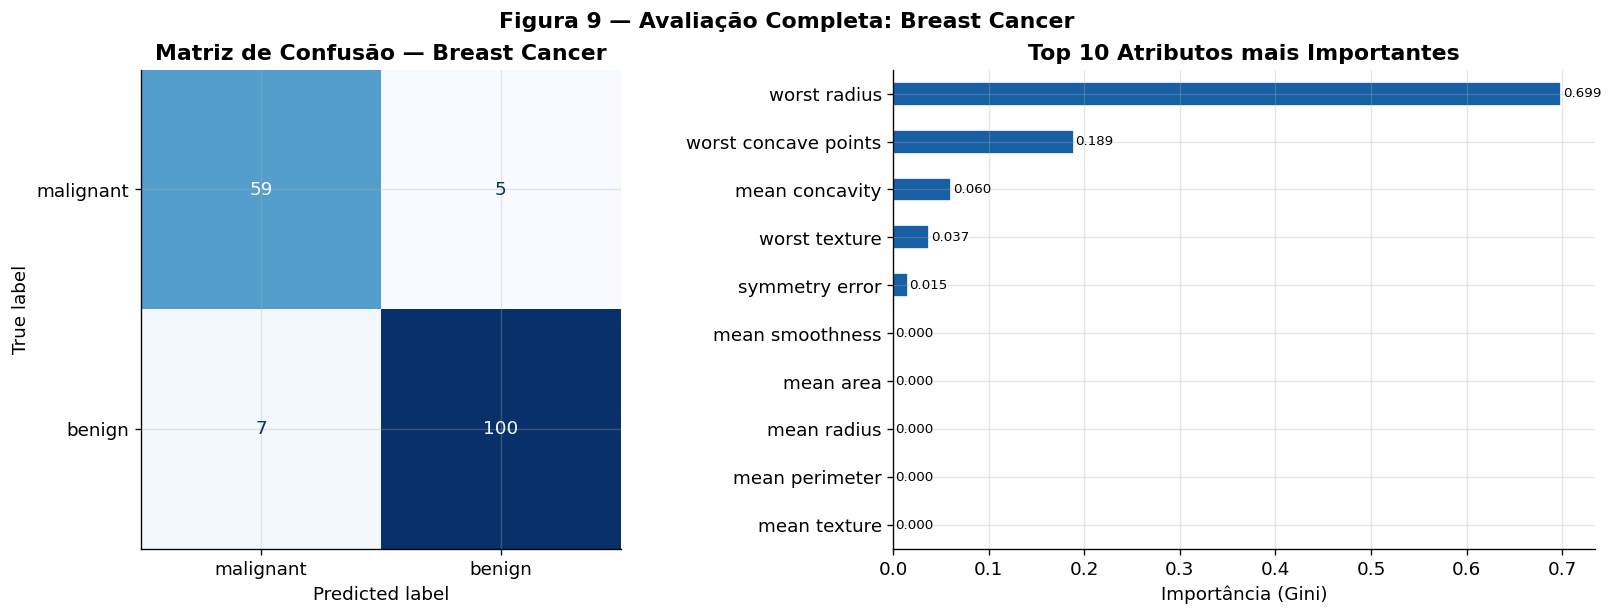

In [ ]:
# ============================================================
# VISUALIZAÇÃO AVANÇADA: Breast Cancer
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusão
ConfusionMatrixDisplay.from_predictions(
    y_bc_te, y_bc_pred,
    display_labels=bc.target_names,
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Matriz de Confusão — Breast Cancer', fontweight='bold')

# Top 10 atributos
fi_bc = pd.Series(clf_bc.feature_importances_, index=bc.feature_names)
fi_bc_top = fi_bc.nlargest(10)
colors_bc = ['#185FA5' if v > fi_bc_top.median() else '#B5D4F4' for v in fi_bc_top]
fi_bc_top.sort_values().plot(kind='barh', ax=axes[1], color=colors_bc[::-1], edgecolor='white')
axes[1].set_title('Top 10 Atributos mais Importantes', fontweight='bold')
axes[1].set_xlabel('Importância (Gini)')
for i, v in enumerate(fi_bc_top.sort_values()):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.suptitle('Figura 9 — Avaliação Completa: Breast Cancer', y=1.02, fontweight='bold')
plt.savefig('fig9_breast_cancer.png', bbox_inches='tight', dpi=130)
plt.show()

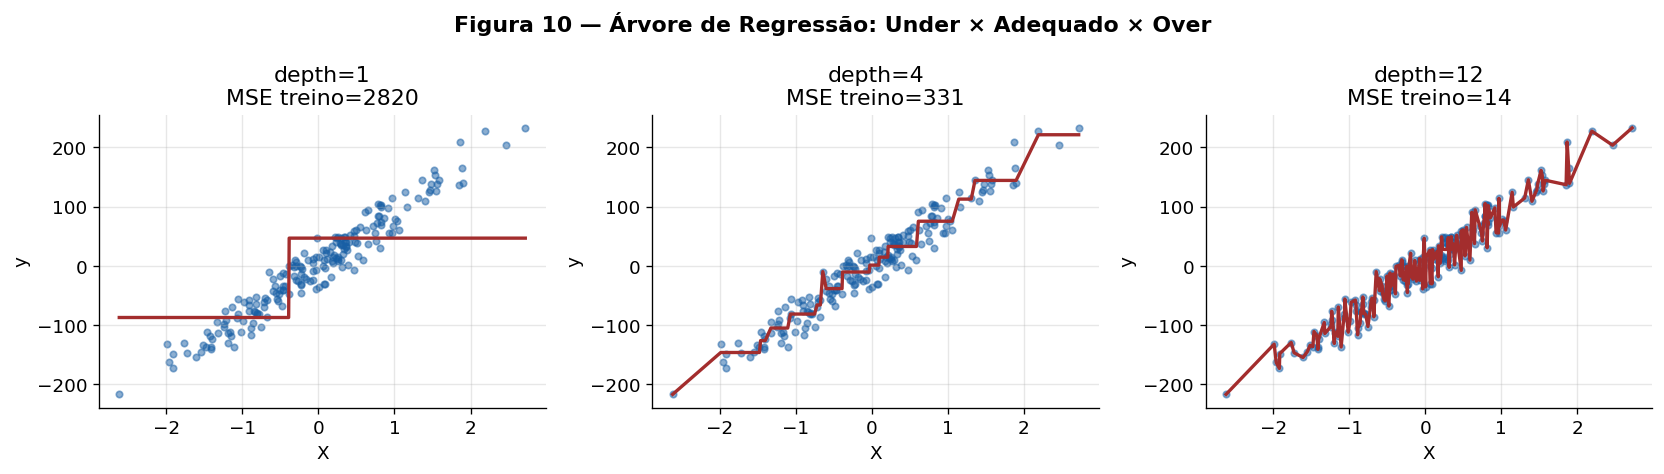

In [ ]:
# ============================================================
# ÁRVORE DE REGRESSÃO — demonstração
# ============================================================
from sklearn.datasets import make_regression

X_reg, y_reg = make_regression(n_samples=200, n_features=1, noise=20, random_state=SEED)
X_reg_s = np.sort(X_reg, axis=0)
y_reg_s = y_reg[np.argsort(X_reg.ravel())]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
depths_reg = [1, 4, 12]
for ax, d in zip(axes, depths_reg):
    reg = DecisionTreeRegressor(max_depth=d, random_state=SEED)
    reg.fit(X_reg, y_reg)
    y_hat = reg.predict(X_reg_s)
    ax.scatter(X_reg, y_reg, s=15, alpha=0.5, color='#185FA5')
    ax.plot(X_reg_s, y_hat, color='#A32D2D', lw=2)
    train_mse = np.mean((reg.predict(X_reg) - y_reg)**2)
    ax.set_title(f'depth={d}\nMSE treino={train_mse:.0f}')
    ax.set_xlabel('X')
    ax.set_ylabel('y')

plt.suptitle('Figura 10 — Árvore de Regressão: Under × Adequado × Over', fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_regressao.png', bbox_inches='tight', dpi=130)
plt.show()

---
## 📝 Exercícios


### 1 — Cálculo Manual

Considere um nó com **8 exemplos Aprovados** e **4 exemplos Reprovados**.

**(a)** Calcule a entropia $H$ deste nó.

**(b)** Calcule o índice de Gini.

**(c)** Se o nó for dividido em dois filhos:
- Filho Esquerdo: 6 Aprovados, 0 Reprovados
- Filho Direito: 2 Aprovados, 4 Reprovados

Qual é o ganho de informação desta divisão?

**(d)** O Filho Esquerdo é puro? Por que nós puros são desejáveis?

In [ ]:
# GABARITO — Exercício 1
def entropia_manual(pos, neg):
    total = pos + neg
    if total == 0: return 0
    p, q = pos/total, neg/total
    h = 0
    if p > 0: h -= p * np.log2(p)
    if q > 0: h -= q * np.log2(q)
    return h

def gini_manual(pos, neg):
    total = pos + neg
    p, q = pos/total, neg/total
    return 1 - p**2 - q**2

# (a) Entropia do nó pai
H_pai = entropia_manual(8, 4)
print(f'(a) Entropia do nó pai: H = {H_pai:.4f}')

# (b) Gini
G_pai = gini_manual(8, 4)
print(f'(b) Índice de Gini:     G = {G_pai:.4f}')

# (c) Ganho de informação
n_total = 12
H_esq = entropia_manual(6, 0)  # puro → H = 0
H_dir = entropia_manual(2, 4)
H_ponderada = (6/n_total)*H_esq + (6/n_total)*H_dir
IG = H_pai - H_ponderada
print(f'(c) H(Filho Esq) = {H_esq:.4f}')
print(f'    H(Filho Dir) = {H_dir:.4f}')
print(f'    H ponderada  = {H_ponderada:.4f}')
print(f'    IG = {H_pai:.4f} - {H_ponderada:.4f} = {IG:.4f}')

# (d)
print(f'(d) Filho esquerdo: H = {H_esq:.4f} → {"PURO" if H_esq == 0 else "NÃO puro"}')
print('    Nós puros → previsão determinística, sem ambiguidade.')

(a) Entropia do nó pai: H = 0.9183
(b) Índice de Gini:     G = 0.4444
(c) H(Filho Esq) = 0.0000
    H(Filho Dir) = 0.9183
    H ponderada  = 0.4591
    IG = 0.9183 - 0.4591 = 0.4591
(d) Filho esquerdo: H = 0.0000 → PURO
    Nós puros → previsão determinística, sem ambiguidade.


---
### 2 - Comparação Gini × Entropy no Dataset Wine

=== Wine Dataset — Comparação de Critérios (sem limite de profundidade) ===
Critério      Depth  Folhas  Acc Treino  Acc Teste
-------------------------------------------------------
gini              4       8       1.000      0.963
entropy           3       6       1.000      0.907


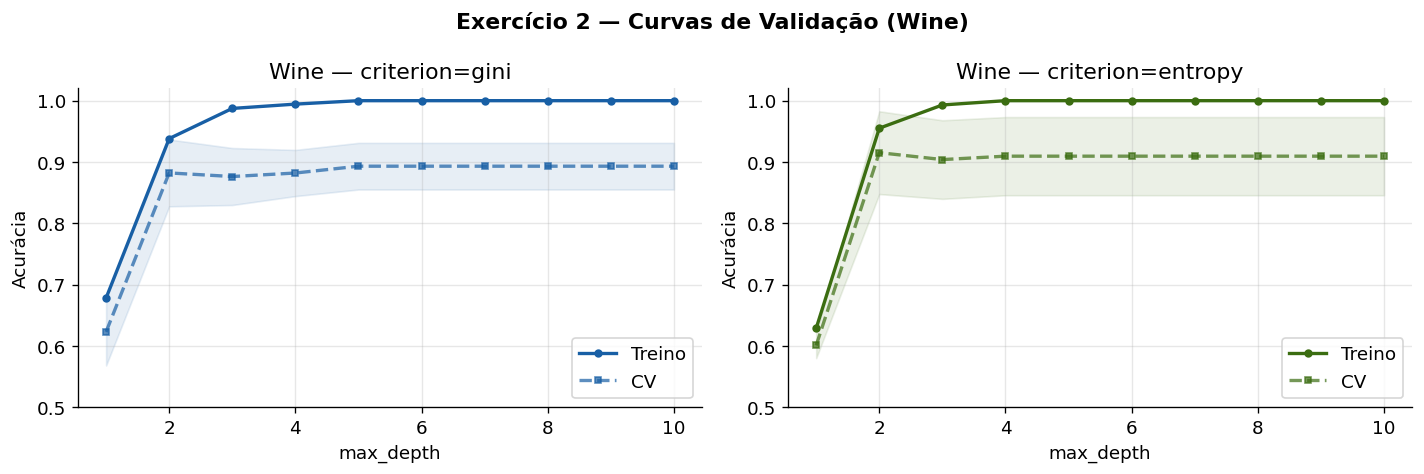

In [ ]:
# EXERCÍCIO 2 — Implemente você mesmo!
# Dica: use load_wine() e siga o template abaixo

wine = load_wine()
X_w, y_w = wine.data, wine.target

# TODO: seu código aqui
# a) Treinar dois modelos sem max_depth
# b) Comparar profundidade, folhas, acurácia treino e teste
# c) Plotar curvas de validação para depth 1..10 com CV-5
# d) Analisar qual critério generalizou melhor

# GABARITO PARCIAL:
X_w_tr, X_w_te, y_w_tr, y_w_te = train_test_split(
    X_w, y_w, test_size=0.3, random_state=SEED, stratify=y_w
)

print('=== Wine Dataset — Comparação de Critérios (sem limite de profundidade) ===')
print(f'{"Critério":12s} {"Depth":>6s} {"Folhas":>7s} {"Acc Treino":>11s} {"Acc Teste":>10s}')
print('-'*55)

for crit in ['gini', 'entropy']:
    clf_w = DecisionTreeClassifier(criterion=crit, random_state=SEED)
    clf_w.fit(X_w_tr, y_w_tr)
    print(f'{crit:12s} {clf_w.get_depth():>6d} {clf_w.get_n_leaves():>7d} '
          f'{clf_w.score(X_w_tr,y_w_tr):>11.3f} {clf_w.score(X_w_te,y_w_te):>10.3f}')

# Curva de validação
depths_w = np.arange(1, 11)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, crit, col in zip(axes, ['gini','entropy'], ['#185FA5','#3B6D11']):
    tr_s, va_s = validation_curve(
        DecisionTreeClassifier(criterion=crit, random_state=SEED),
        X_w, y_w, param_name='max_depth', param_range=depths_w,
        cv=StratifiedKFold(5,shuffle=True,random_state=SEED), scoring='accuracy'
    )
    ax.plot(depths_w, tr_s.mean(1), color=col, lw=2, ls='-',  marker='o', ms=4, label='Treino')
    ax.plot(depths_w, va_s.mean(1), color=col, lw=2, ls='--', marker='s', ms=4, alpha=0.7, label='CV')
    ax.fill_between(depths_w, va_s.mean(1)-va_s.std(1), va_s.mean(1)+va_s.std(1), alpha=0.1, color=col)
    ax.set_title(f'Wine — criterion={crit}')
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Acurácia')
    ax.legend()
    ax.set_ylim(0.5, 1.02)

plt.suptitle('Exercício 2 — Curvas de Validação (Wine)', fontweight='bold')
plt.tight_layout()
plt.show()

---
### 3 — Diagnóstico de Over/Underfitting

Analise a tabela abaixo e responda:

| Modelo | Acc. Treino | Acc. Validação | max_depth |
|---|---|---|---|
| A | 99.8% | 72.1% | None |
| B | 84.5% | 83.9% | 5 |
| C | 67.2% | 66.8% | 2 |

**(a)** Qual modelo tem overfitting? Underfitting? Generalização adequada?

**(b)** Para o modelo com overfitting, sugira 3 técnicas concretas.

**(c)** Por que o gap Treino × Validação é o diagnóstico mais confiável?

=== GABARITO — Exercício 3 ===

(a) Diagnóstico:
    Modelo A → OVERFITTING  (gap = 27.7%! Memoriza o treino)
    Modelo B → ADEQUADO     (gap = 0.6%. Generaliza bem)
    Modelo C → UNDERFITTING (ambos baixos. Modelo muito simples)

(b) Técnicas para corrigir Modelo A (Overfitting):
    1. Limitar max_depth (ex: 5 a 8)
    2. Aumentar min_samples_leaf (ex: 5 a 10)
    3. Aplicar pós-poda: ccp_alpha via cost_complexity_pruning_path()
    Bônus: usar GridSearchCV + CV-5 para encontrar hiperparâmetros ótimos

(c) O gap é o diagnóstico mais confiável porque:
    - Acurácia isolada pode enganar (99.8% no treino parece ótimo)
    - O gap revela se o modelo aprendeu os dados ou só os memorizou
    - Gap < 5% = modelo generaliza; Gap > 10% = overfitting grave


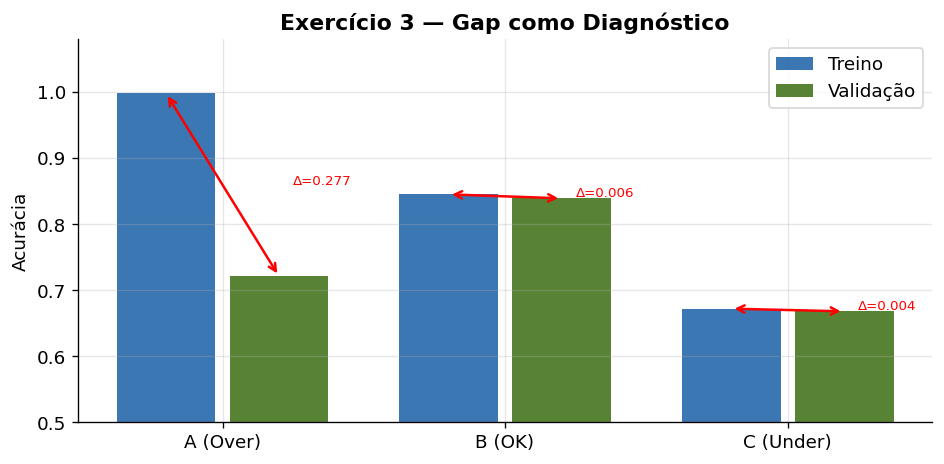

In [ ]:
# GABARITO — Exercício 3
print('=== GABARITO — Exercício 3 ===')
print()
print('(a) Diagnóstico:')
print('    Modelo A → OVERFITTING  (gap = 27.7%! Memoriza o treino)')
print('    Modelo B → ADEQUADO     (gap = 0.6%. Generaliza bem)')
print('    Modelo C → UNDERFITTING (ambos baixos. Modelo muito simples)')
print()
print('(b) Técnicas para corrigir Modelo A (Overfitting):')
print('    1. Limitar max_depth (ex: 5 a 8)')
print('    2. Aumentar min_samples_leaf (ex: 5 a 10)')
print('    3. Aplicar pós-poda: ccp_alpha via cost_complexity_pruning_path()')
print('    Bônus: usar GridSearchCV + CV-5 para encontrar hiperparâmetros ótimos')
print()
print('(c) O gap é o diagnóstico mais confiável porque:')
print('    - Acurácia isolada pode enganar (99.8% no treino parece ótimo)')
print('    - O gap revela se o modelo aprendeu os dados ou só os memorizou')
print('    - Gap < 5% = modelo generaliza; Gap > 10% = overfitting grave')

# Visualização dos três modelos
fig, ax = plt.subplots(figsize=(8, 4))
modelos = ['A (Over)', 'B (OK)', 'C (Under)']
treino = [0.998, 0.845, 0.672]
valid  = [0.721, 0.839, 0.668]

x = np.arange(3)
ax.bar(x - 0.2, treino, 0.35, color='#185FA5', label='Treino', alpha=0.85)
ax.bar(x + 0.2, valid,  0.35, color='#3B6D11', label='Validação', alpha=0.85)

for i, (t, v) in enumerate(zip(treino, valid)):
    ax.annotate('', xy=(i+0.2, v), xytext=(i-0.2, t),
                arrowprops=dict(arrowstyle='<->', color='red', lw=1.5))
    ax.text(i+0.25, (t+v)/2, f'Δ={abs(t-v):.3f}', fontsize=8, color='red')

ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.set_ylabel('Acurácia')
ax.set_title('Exercício 3 — Gap como Diagnóstico', fontweight='bold')
ax.legend()
ax.set_ylim(0.5, 1.08)
plt.tight_layout()
plt.show()

---
### 4 — Pipeline Completo com GridSearchCV

In [ ]:
# EXERCÍCIO 4 — Pipeline completo: Breast Cancer
# TODO: implemente você mesmo e compare com o gabarito abaixo

# GABARITO:
bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target
X_bc_tr, X_bc_te, y_bc_tr, y_bc_te = train_test_split(
    X_bc, y_bc, test_size=0.3, random_state=SEED, stratify=y_bc
)

# a) GridSearchCV
gs4 = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED),
    {'criterion':['gini','entropy'], 'max_depth':[3,5,7,None],
     'min_samples_leaf':[1,5,10]},
    cv=StratifiedKFold(5,shuffle=True,random_state=SEED),
    scoring='f1', n_jobs=-1
)
gs4.fit(X_bc_tr, y_bc_tr)
clf4 = gs4.best_estimator_

print('Melhores parâmetros:', gs4.best_params_)
y4_pred = clf4.predict(X_bc_te)
print('\n' + classification_report(y_bc_te, y4_pred, target_names=bc.target_names))

# b) Pós-poda
path4 = clf4.cost_complexity_pruning_path(X_bc_tr, y_bc_tr)
alphas4 = path4.ccp_alphas[:-1]
f1_alphas = []
from sklearn.metrics import f1_score
for alpha in alphas4:
    c = DecisionTreeClassifier(**{k:v for k,v in gs4.best_params_.items()}, ccp_alpha=alpha, random_state=SEED)
    c.fit(X_bc_tr, y_bc_tr)
    f1_alphas.append(f1_score(y_bc_te, c.predict(X_bc_te)))

best_alpha4 = alphas4[np.argmax(f1_alphas)]
print(f'Alpha ótimo após poda: {best_alpha4:.5f}')
print(f'F1 com poda:           {max(f1_alphas):.4f}')
print(f'F1 sem poda:           {f1_score(y_bc_te, y4_pred):.4f}')

Melhores parâmetros: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 10}

              precision    recall  f1-score   support

   malignant       0.89      0.92      0.91        64
      benign       0.95      0.93      0.94       107

    accuracy                           0.93       171
   macro avg       0.92      0.93      0.93       171
weighted avg       0.93      0.93      0.93       171

Alpha ótimo após poda: 0.00000
F1 com poda:           0.9434
F1 sem poda:           0.9434


---
### 5 — Análise Crítica

**(a)** Por que árvores de decisão são instáveis (alta variância)? Como o Random Forest resolve?

**(b)** Um atributo com 100 valores únicos pode inflar artificialmente o IG. Qual critério do C4.5 corrige?

**(c)** Árvores de decisão são sensíveis a escala dos atributos? Compare com SVM e KNN.

**(d)** Cite um caso onde uma árvore simples e interpretável é preferível ao XGBoost.

In [ ]:
# GABARITO — Exercício 5
print('=== GABARITO — Exercício 5 ===')
print()
print('(a) INSTABILIDADE:')
print('    Árvores têm alta variância porque pequenas mudanças nos dados')
print('    podem mudar o atributo escolhido na raiz → toda estrutura muda.')
print('    Random Forest: bootstrap (bagging) + feature sampling aleatório')
print('    → árvores decorrelacionadas → média reduz variância.')
print()
print('(b) VIÉS DO IG:')
print('    Razão de Ganho (C4.5): GR(A) = IG(A) / SplitInfo(A)')
print('    SplitInfo = entropia da distribuição dos valores de A')
print('    → penaliza atributos com muitos valores (ID único → GR ≈ 0)')
print()
print('(c) INVARIÂNCIA A ESCALA:')
print('    Árvores: SIM, invariantes. Divisões são baseadas em rank/ordem,')
print('    não em distâncias. Ex: salário em R$ ou em k$ → mesma árvore.')
print('    SVM: NÃO, precisa de normalização (kernels usam distâncias).')
print('    KNN: NÃO, distância euclidiana sensível a escala.')
print()
print('(d) INTERPRETABILIDADE > ACURÁCIA:')
print('    - Concessão de crédito bancário (LGPD: direito à explicação)')
print('    - Diagnóstico médico com auditoria')
print('    - Sistemas embarcados com memória limitada')
print('    - Treinamento de médicos/gestores com regras simples')

# Demonstração: instabilidade das árvores
print('\n=== Demonstração de Instabilidade ===')
np.random.seed(SEED)
n_runs = 10
raizes = []
for i in range(n_runs):
    # Pequena perturbação (1 amostra diferente)
    idx = np.random.choice(len(X_iris), size=int(0.9*len(X_iris)), replace=False)
    clf_inst = DecisionTreeClassifier(random_state=i)
    clf_inst.fit(X_iris[idx], y_iris[idx])
    raiz_feat = iris.feature_names[clf_inst.tree_.feature[0]]
    raizes.append(raiz_feat)
    print(f'  Run {i+1:2d}: raiz = {raiz_feat}')

from collections import Counter
print(f'\n  Distribuição das raízes: {dict(Counter(raizes))}')
print('  → A raiz muda entre runs! Alta instabilidade.')

=== GABARITO — Exercício 5 ===

(a) INSTABILIDADE:
    Árvores têm alta variância porque pequenas mudanças nos dados
    podem mudar o atributo escolhido na raiz → toda estrutura muda.
    Random Forest: bootstrap (bagging) + feature sampling aleatório
    → árvores decorrelacionadas → média reduz variância.

(b) VIÉS DO IG:
    Razão de Ganho (C4.5): GR(A) = IG(A) / SplitInfo(A)
    SplitInfo = entropia da distribuição dos valores de A
    → penaliza atributos com muitos valores (ID único → GR ≈ 0)

(c) INVARIÂNCIA A ESCALA:
    Árvores: SIM, invariantes. Divisões são baseadas em rank/ordem,
    não em distâncias. Ex: salário em R$ ou em k$ → mesma árvore.
    SVM: NÃO, precisa de normalização (kernels usam distâncias).
    KNN: NÃO, distância euclidiana sensível a escala.

(d) INTERPRETABILIDADE > ACURÁCIA:
    - Concessão de crédito bancário (LGPD: direito à explicação)
    - Diagnóstico médico com auditoria
    - Sistemas embarcados com memória limitada
    - Treinamento de médicos

---
## 🔗 Próximos Passos e Referências

### Pipeline de Extensão: de Árvore a Ensemble

[![](https://mermaid.ink/img/pako:eNpNk0tu2zAQhq9CMJsWtV2J1htFAD9io2iCAHEWRasuxuJIJiqJKkUVdRwvepYueoKewBcrZcu2tKKI7_84Qwx3NJEcaUQzBdWG3D_FJTHf5M3XmB5-q59SIeFI5piI-vBHxvTbWzIc3r7GdApZJsrsw1rdviMLBN0YdAVFlZvdmL6Saet4gpLLgiyMp9ZtuvOfJVLWurOs8EeDZSIgb9OzNr1UwAWWmpy5q2HWGR61KMQLcNmG5m3o8_JIk_fkXmQbvZw-XFPTLjXJNRBRalSVQg1rkQsOHFvHXes49_OxqKTSUCZ4dcw7x-rxeUKeYd3koNrgog3OZFGhFoe_h39Yk0_mjvIuegrXepujaT8VeR7d8DVCioNaK_kdoxubO8iDPjg9g0maoH8FPRg70AdnHZhiGibjC5hAAJbTB-cXEBmyC8gT5jGvD951IFop69VoscBJ_D64OBtNhen16DXagcvpgBaoChDczNiujcVUb7AwlxKZJccUmtwMRlzuDQqNlqttmdBIqwYHVMkm29Aohbw2f03FQeNcgJnV4rJbQUmjHf1Fo6E_CizPt1w_ZL5l-V4woFsa2aE3csfMdl2f-Q6z3P2AvkhpDNYo9JyQhb4buhZzbHtAkQst1cPpTRyfxvGEL0f-VFSm2ma6ArHkqGayKTWNWDDe_wcq4Qz7?type=png)](https://mermaid.live/edit#pako:eNpNk0tu2zAQhq9CMJsWtV2J1htFAD9io2iCAHEWRasuxuJIJiqJKkUVdRwvepYueoKewBcrZcu2tKKI7_84Qwx3NJEcaUQzBdWG3D_FJTHf5M3XmB5-q59SIeFI5piI-vBHxvTbWzIc3r7GdApZJsrsw1rdviMLBN0YdAVFlZvdmL6Saet4gpLLgiyMp9ZtuvOfJVLWurOs8EeDZSIgb9OzNr1UwAWWmpy5q2HWGR61KMQLcNmG5m3o8_JIk_fkXmQbvZw-XFPTLjXJNRBRalSVQg1rkQsOHFvHXes49_OxqKTSUCZ4dcw7x-rxeUKeYd3koNrgog3OZFGhFoe_h39Yk0_mjvIuegrXepujaT8VeR7d8DVCioNaK_kdoxubO8iDPjg9g0maoH8FPRg70AdnHZhiGibjC5hAAJbTB-cXEBmyC8gT5jGvD951IFop69VoscBJ_D64OBtNhen16DXagcvpgBaoChDczNiujcVUb7AwlxKZJccUmtwMRlzuDQqNlqttmdBIqwYHVMkm29Aohbw2f03FQeNcgJnV4rJbQUmjHf1Fo6E_CizPt1w_ZL5l-V4woFsa2aE3csfMdl2f-Q6z3P2AvkhpDNYo9JyQhb4buhZzbHtAkQst1cPpTRyfxvGEL0f-VFSm2ma6ArHkqGayKTWNWDDe_wcq4Qz7)


## Referências Fundamentais

| Referência | Contribuição |
|---|---|
| Quinlan, J.R. (1986). *Induction of Decision Trees.* Machine Learning. | Algoritmo ID3 |
| Quinlan, J.R. (1993). *C4.5: Programs for Machine Learning.* Morgan Kaufmann. | C4.5 |
| Breiman, L. et al. (1984). *Classification and Regression Trees.* Wadsworth. | CART |
| Mitchell, T. (1997). *Machine Learning.* McGraw-Hill. | Play Tennis dataset |
| Pedregosa et al. (2011). *Scikit-learn.* JMLR 12, 2825–2830. | scikit-learn |

## Leituras Complementares

- [scikit-learn Decision Trees](https://scikit-learn.org/stable/modules/tree.html)
- [Documentação: DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)
- [Breiman (2001). Random Forests. Machine Learning, 45, 5–32.](https://link.springer.com/article/10.1023/A:1010933404324)

## Resumo

```plain
═════════════════════════════════════════════════════════════════
  RESUMO DA AULA — ÁRVORES DE DECISÃO
═════════════════════════════════════════════════════════════════

  CRITÉRIOS DE IMPUREZA:
  • Entropia: ID3/C4.5 · sensível a pequenas variações
  • Gini:     CART      · padrão scikit-learn · mais rápido
  • MSE/MAE:  Regressão

  QUANDO USAR CADA UM:
  • Gini:     casos gerais (padrão)
  • Entropy:  classes desbalanceadas, máxima informação
  • Ratio IG: muitos valores categóricos (C4.5)

  EVITAR OVERFITTING:
  • Pré-poda:  max_depth · min_samples_split · min_samples_leaf
  • Pós-poda:  ccp_alpha via cost_complexity_pruning_path()
  • Validação: CV-5 ou CV-10 + curva de validação

  LIMITAÇÕES → SOLUÇÕES:
  • Alta variância    → Random Forest (bagging)
  • Fronteiras retas  → SVM com kernel / Redes Neurais
  • Não extrapola     → Gradient Boosting

  ✅ Acurácia final no Iris (melhor modelo): 97.78%
═════════════════════════════════════════════════════════════════
```